# DATA266 Lab 1 Part 3 - Anushka

This notebook trains and evaluates a CycleGAN from scratch for unpaired Monet <-> Photo translation.

# Task 3 CycleGAN Image Style Transfer

**Role:** Generative Modeling Researcher, Computer Vision Team

This notebook follows the Task 3 requirements from the lab PDF.

- Domain **A = Monet paintings**, domain **B = photos**.
- `G_A2B`: Monet -> Photo, `G_B2A`: Photo -> Monet, `D_A`: real vs generated Monet, `D_B`: real vs generated photo.

No pretrained model is used for training or for producing the translated images. Pretrained networks
(InceptionV3, AlexNet-LPIPS) appear only in section 3.2, as fixed measuring instruments for the metrics.

## 3.1 Model Implementation and Training

This section:
- Prepares the two unpaired image domains.
- Implements two ResNet generators and two 70x70 PatchGAN discriminators.
- Trains with least-squares adversarial loss, cycle-consistency loss and identity loss.
- Logs losses, gradient norms and non-finite steps for the stability analysis.

In [1]:
from pathlib import Path
import csv, json, math, os, platform, random, resource, shutil, subprocess, sys, time

# Repo-relative paths (no personal paths). This notebook lives in
# task3_gan/member_anushka/src/, so walk up until the repo root is found.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'task3_gan').is_dir())
MEMBER_NAME = 'anushka'
MEMBER_DIR = REPO_ROOT / 'task3_gan' / f'member_{MEMBER_NAME}'

DATA_DIR = REPO_ROOT / 'task3_gan' / 'data'           # shared raw images (gitignored)
CHECKPOINT_DIR = MEMBER_DIR / 'checkpoints'
OUTPUT_DIR = MEMBER_DIR / 'outputs'
CONFIG_DIR = MEMBER_DIR / 'src'
LOG_DIR = REPO_ROOT / 'reproducibility' / 'raw_logs' / f'task3_gan_{MEMBER_NAME}'
MANIFEST_DIR = REPO_ROOT / 'reproducibility' / 'manifests'

for folder in [CHECKPOINT_DIR, OUTPUT_DIR, LOG_DIR, MANIFEST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def rel(path):
    return Path(path).relative_to(REPO_ROOT).as_posix()

print('Repo root:', REPO_ROOT)
print('Member folder:', MEMBER_DIR)

Repo root: /app
Member folder: /app/task3_gan/member_anushka


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from PIL import Image

set_matplotlib_formats('jpeg')     # image-heavy figures: keeps the executed notebook small

# Every hyperparameter comes from src/config.json.
CONFIG = json.loads((CONFIG_DIR / 'config.json').read_text())

# Full training run by default. Set env var TASK3_SMOKE=1 for a short smoke test
# (2 epochs on a small image subset) - used by the README one-command reproduction.
SMOKE = os.environ.get('TASK3_SMOKE', '0') == '1'
if SMOKE:
    CONFIG.update({
        'max_photos': 96, 'max_monets': 32, 'photo_holdout': 32,
        'epochs_constant_lr': 1, 'epochs_linear_decay': 1,
        'checkpoint_every_epochs': 1, 'log_every_steps': 16,
    })

# Set env var TASK3_RESUME=<file name in checkpoints/, or repo-relative path> to continue an interrupted run
# (same run ID, same raw log). Resuming from the last epoch only re-runs the evaluation.
RESUME_FROM = os.environ.get('TASK3_RESUME', '')
resume_state = None
if RESUME_FROM:
    resume_path = REPO_ROOT / RESUME_FROM if (REPO_ROOT / RESUME_FROM).is_file() else CHECKPOINT_DIR / RESUME_FROM
    resume_state = torch.load(resume_path, map_location='cpu', weights_only=False)
    CONFIG, SMOKE = resume_state['config'], resume_state['run_kind'] == 'smoke'
    RUN_ID = resume_state['run_id']
else:
    RUN_ID = time.strftime('%Y%m%d_%H%M%S')

RUN_KIND = 'smoke' if SMOKE else 'full'
RUN_DIR = OUTPUT_DIR / f'{RUN_KIND}_run_{RUN_ID}'
(RUN_DIR / 'samples').mkdir(parents=True, exist_ok=True)

# A smoke test keeps everything inside its own run folder so it never overwrites the results of a full run.
RUN_CHECKPOINT_DIR = RUN_DIR / 'checkpoints' if SMOKE else CHECKPOINT_DIR
PRED_ROOT = RUN_DIR if SMOKE else OUTPUT_DIR          # pred_A2B/ and pred_B2A/ live here
REPORT_DIR = RUN_DIR if SMOKE else MEMBER_DIR         # metrics CSVs and submission.csv live here
RUN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = LOG_DIR / f'{RUN_KIND}_training_log_{RUN_ID}.txt'

def log(message):
    line = f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {message}"
    print(line, flush=True)
    with LOG_PATH.open('a', encoding='utf-8') as f:
        f.write(line + '\n')

TOTAL_EPOCHS = CONFIG['epochs_constant_lr'] + CONFIG['epochs_linear_decay']
(RUN_DIR / 'config.json').write_text(json.dumps(CONFIG, indent=2))
log(f"{'RESUME from ' + RESUME_FROM if RESUME_FROM else 'START'} run_id={RUN_ID} kind={RUN_KIND}")
log('config: ' + json.dumps(CONFIG))

[2026-10-01 22:27:45] START run_id=20261001_222745 kind=full


[2026-10-01 22:27:45] config: {"member": "Anushka", "seed": 3963, "image_size": 256, "load_size": 286, "photo_holdout": 1000, "generator_base_channels": 64, "generator_residual_blocks": 9, "discriminator_base_channels": 64, "lambda_cycle": 10.0, "lambda_identity": 5.0, "learning_rate": 0.0002, "adam_betas": [0.5, 0.999], "batch_size": 1, "torch_compile": true, "epochs_constant_lr": 25, "epochs_linear_decay": 25, "image_pool_size": 50, "weight_init_std": 0.02, "checkpoint_every_epochs": 5, "log_every_steps": 500, "eval_batch_size": 50, "kid_subsets": 100, "kid_subset_size": 1000, "prdc_k": 5, "audit_samples": 30}


In [3]:
SEED = CONFIG['seed']
start_epoch = resume_state['epoch'] + 1 if resume_state else 1
# A resumed run continues with a different random stream than the epochs already done.
random.seed(SEED + start_epoch - 1)
np.random.seed(SEED + start_epoch - 1)
torch.manual_seed(SEED + start_epoch - 1)
data_rng = torch.Generator().manual_seed(SEED + start_epoch - 1)   # sampling order and augmentation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

def cpu_name():
    try:
        for line in Path('/proc/cpuinfo').read_text().splitlines():
            if line.startswith('model name'):
                return line.split(':', 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()

HARDWARE = {
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none (CPU run)',
    'gpu_memory_gb': round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1) if torch.cuda.is_available() else 0,
    'cpu': cpu_name(),
}
log(f"PyTorch {torch.__version__} | CUDA build {torch.version.cuda} | device {device} | hardware {json.dumps(HARDWARE)}")
if torch.cuda.is_available():
    # Fails fast if this PyTorch build has no kernels for the GPU.
    _ = (torch.ones(2, 2, device=device) @ torch.ones(2, 2, device=device)).sum().item()
    print('GPU kernel check: OK')

def sync():
    if device.type == 'cuda':
        torch.cuda.synchronize()

[2026-10-01 22:27:45] PyTorch 2.8.0+cu128 | CUDA build 12.8 | device cuda | hardware {"gpu": "NVIDIA GeForce RTX 4090", "gpu_memory_gb": 24.0, "cpu": "AMD Ryzen 9 7950X 16-Core Processor"}


GPU kernel check: OK


### Two unpaired image domains

The Monet and photo folders are unrelated sets: no photo has a matching painting. A fixed set of photos is
held out and never trained on; it is the test set for Photo -> Monet. There are only 300 Monet paintings,
so all of them are used for training and Monet -> Photo is evaluated on those same paintings.

All images are decoded once and kept in memory. Training images are stored at `load_size` and get a random
crop to `image_size` plus a random horizontal flip at every step. Evaluation images are resized straight to
`image_size` with no augmentation.

In [4]:
from concurrent.futures import ThreadPoolExecutor

def list_images(folder):
    return sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in ('.jpg', '.jpeg', '.png'))

def load_images(files, size):
    """Decode and resize to size x size. Returns a uint8 tensor [N, 3, size, size]."""
    def load_one(path):
        with Image.open(path) as img:
            return np.asarray(img.convert('RGB').resize((size, size), Image.BICUBIC))
    with ThreadPoolExecutor(16) as pool:
        arrays = list(pool.map(load_one, files))
    return torch.from_numpy(np.stack(arrays)).permute(0, 3, 1, 2).contiguous()

monet_files = list_images(DATA_DIR / 'monet_jpg')
photo_files = list_images(DATA_DIR / 'photo_jpg')
if not monet_files or not photo_files:
    raise FileNotFoundError(f'Put the images in {rel(DATA_DIR)}/monet_jpg and {rel(DATA_DIR)}/photo_jpg')
if CONFIG.get('max_monets'):
    monet_files = monet_files[:CONFIG['max_monets']]
if CONFIG.get('max_photos'):
    photo_files = photo_files[:CONFIG['max_photos']]

# My own split: photos are shuffled with my seed and the first `photo_holdout` are held out.
split_order = np.random.default_rng(SEED).permutation(len(photo_files))
photo_eval_files = sorted(photo_files[i] for i in split_order[:CONFIG['photo_holdout']])
photo_train_files = sorted(photo_files[i] for i in split_order[CONFIG['photo_holdout']:])
(RUN_DIR / 'photo_holdout_files.txt').write_text('\n'.join(p.name for p in photo_eval_files) + '\n')

IMAGE_SIZE, LOAD_SIZE = CONFIG['image_size'], CONFIG['load_size']
t0 = time.perf_counter()
train_monet = load_images(monet_files, LOAD_SIZE)
train_photo = load_images(photo_train_files, LOAD_SIZE)
eval_monet = load_images(monet_files, IMAGE_SIZE)
eval_photo = load_images(photo_eval_files, IMAGE_SIZE)
log(f'data: monet train/eval={len(train_monet)}/{len(eval_monet)} (same paintings) '
    f'photo train/eval={len(train_photo)}/{len(eval_photo)} loaded in {time.perf_counter() - t0:.1f}s')

def to_float(images_u8):
    """uint8 [0, 255] -> float [-1, 1], the range of the generator's tanh output."""
    return images_u8.float() / 127.5 - 1.0

def to_uint8(images):
    return ((images.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

def augment(images_u8):
    """Random crop to image_size and random horizontal flip, per image."""
    out = []
    for img in images_u8:
        top, left = torch.randint(0, LOAD_SIZE - IMAGE_SIZE + 1, (2,), generator=data_rng).tolist()
        crop = img[:, top:top + IMAGE_SIZE, left:left + IMAGE_SIZE]
        if torch.rand(1, generator=data_rng).item() < 0.5:
            crop = crop.flip(-1)
        out.append(crop)
    return to_float(torch.stack(out).to(device, non_blocking=True))

[2026-10-01 22:27:53] data: monet train/eval=300/300 (same paintings) photo train/eval=6038/1000 loaded in 7.9s


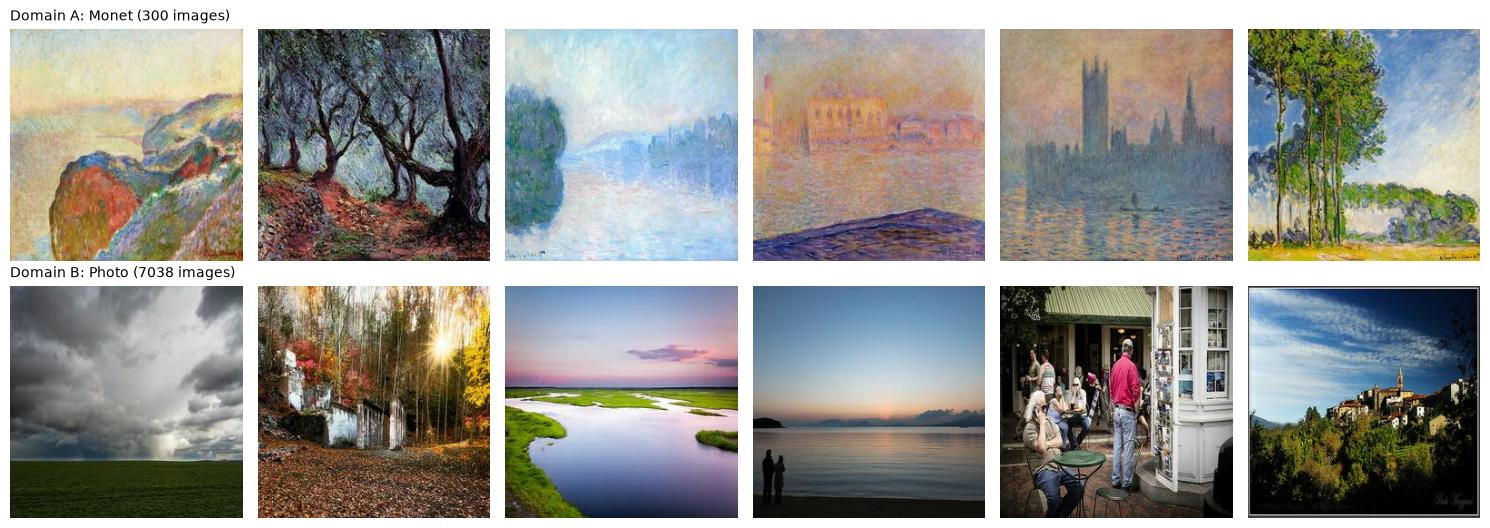

monet: mean RGB [0.521, 0.524, 0.477] std RGB [0.227, 0.22, 0.247]


photo: mean RGB [0.403, 0.409, 0.385] std RGB [0.268, 0.247, 0.275]


In [5]:
def show_row(ax_row, images_u8, title):
    for ax, img in zip(ax_row, images_u8):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis('off')
    ax_row[0].set_title(title, loc='left', fontsize=10)

fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
show_row(axes[0], eval_monet[:6], f'Domain A: Monet ({len(monet_files)} images)')
show_row(axes[1], eval_photo[:6], f'Domain B: Photo ({len(photo_files)} images)')
fig.tight_layout()
fig.savefig(RUN_DIR / 'domain_samples.jpg', dpi=110)
plt.show()

for name, images in [('monet', eval_monet), ('photo', eval_photo)]:
    x = images.float() / 255
    print(f'{name}: mean RGB {[round(v, 3) for v in x.mean((0, 2, 3)).tolist()]} '
          f'std RGB {[round(v, 3) for v in x.std((0, 2, 3)).tolist()]}')

### CycleGAN networks

- **Generator** (x2): 7x7 stem -> two stride-2 downsampling convolutions -> residual blocks -> two
  transposed-convolution upsampling layers -> 7x7 output with tanh. Instance normalization throughout.
- **Discriminator** (x2): 70x70 PatchGAN. It outputs a grid of real/fake scores, one per overlapping
  70x70 patch of the input, instead of one score for the whole image.

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNetGenerator(nn.Module):
    def __init__(self, base_channels, n_residual_blocks):
        super().__init__()
        c = base_channels
        self.stem = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, c, kernel_size=7),
            nn.InstanceNorm2d(c),
            nn.ReLU(inplace=True),
        )
        self.down = nn.Sequential(
            nn.Conv2d(c, 2 * c, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(2 * c),
            nn.ReLU(inplace=True),
            nn.Conv2d(2 * c, 4 * c, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(4 * c),
            nn.ReLU(inplace=True),
        )
        self.residual = nn.Sequential(*[ResidualBlock(4 * c) for _ in range(n_residual_blocks)])
        self.up = nn.Sequential(
            nn.ConvTranspose2d(4 * c, 2 * c, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(2 * c),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(2 * c, c, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(c),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(c, 3, kernel_size=7),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.head(self.up(self.residual(self.down(self.stem(x)))))


class PatchGANDiscriminator(nn.Module):
    def __init__(self, base_channels):
        super().__init__()
        c = base_channels
        self.layers = nn.Sequential(
            nn.Conv2d(3, c, kernel_size=4, stride=2, padding=1),          # no normalization on the first layer
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(c, 2 * c, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(2 * c),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(2 * c, 4 * c, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(4 * c),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4 * c, 8 * c, kernel_size=4, stride=1, padding=1),
            nn.InstanceNorm2d(8 * c),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(8 * c, 1, kernel_size=4, stride=1, padding=1),      # one real/fake score per patch
        )

    def forward(self, x):
        return self.layers(x)


def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight, mean=0.0, std=CONFIG['weight_init_std'])
        nn.init.zeros_(module.bias)

def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

G_A2B = ResNetGenerator(CONFIG['generator_base_channels'], CONFIG['generator_residual_blocks'])   # Monet -> Photo
G_B2A = ResNetGenerator(CONFIG['generator_base_channels'], CONFIG['generator_residual_blocks'])   # Photo -> Monet
D_A = PatchGANDiscriminator(CONFIG['discriminator_base_channels'])                                # real vs fake Monet
D_B = PatchGANDiscriminator(CONFIG['discriminator_base_channels'])                                # real vs fake Photo
NETS = {'G_A2B': G_A2B, 'G_B2A': G_B2A, 'D_A': D_A, 'D_B': D_B}
for net in NETS.values():
    net.apply(init_weights)
    net.to(device)

PARAMETER_COUNT = {name: count_parameters(net) for name, net in NETS.items()}
PARAMETER_COUNT['total'] = sum(PARAMETER_COUNT.values())
log(f'parameters: {json.dumps(PARAMETER_COUNT)}')

[2026-10-01 22:27:54] parameters: {"G_A2B": 11378179, "G_B2A": 11378179, "D_A": 2764737, "D_B": 2764737, "total": 28285832}


In [7]:
# Shape check: the generator keeps the image size, the discriminator returns a grid of patch scores.
with torch.no_grad():
    sample = augment(train_monet[:1])
    translated = G_A2B(sample)
    patch_scores = D_B(translated)
print('Input:', tuple(sample.shape), '| value range', round(sample.min().item(), 2), 'to', round(sample.max().item(), 2))
print('Generator output:', tuple(translated.shape))
print('Discriminator output:', tuple(patch_scores.shape))

# Receptive field of one discriminator output cell, from the (kernel, stride) of each convolution.
receptive_field, jump = 1, 1
for kernel, stride in [(4, 2), (4, 2), (4, 2), (4, 1), (4, 1)]:
    receptive_field += (kernel - 1) * jump
    jump *= stride
print('Discriminator receptive field:', receptive_field, 'x', receptive_field)

Input: (1, 3, 256, 256) | value range -0.97 to 1.0
Generator output: (1, 3, 256, 256)
Discriminator output: (1, 1, 30, 30)
Discriminator receptive field: 70 x 70


### Losses, optimizers and schedule

- **Adversarial loss:** least-squares GAN (MSE against 1 for real and 0 for fake).
- **Cycle-consistency loss:** L1 between an image and its reconstruction after a round trip through both
  generators, in both directions, weighted by `lambda_cycle`.
- **Identity loss:** L1 between a target-domain image and the generator's output for it, weighted by
  `lambda_identity`.
- The discriminators see generated images drawn from a history pool of past generations.
- Adam for both; the learning rate is constant for the first phase and then decays linearly towards zero.

In [8]:
class ImagePool:
    """History of generated images. With probability 0.5 the discriminator is shown an older
    generated image from the pool instead of the newest one."""
    def __init__(self, size):
        self.size = size
        self.images = []

    def query(self, batch):
        if self.size == 0:
            return batch
        out = []
        for image in batch:
            image = image.unsqueeze(0)
            if len(self.images) < self.size:
                self.images.append(image)
                out.append(image)
            elif random.random() < 0.5:
                slot = random.randrange(self.size)
                out.append(self.images[slot])
                self.images[slot] = image
            else:
                out.append(image)
        return torch.cat(out)


def set_requires_grad(nets, flag):
    for net in nets:
        for p in net.parameters():
            p.requires_grad_(flag)

def gradient_norm(parameters):
    return torch.nn.utils.get_total_norm([p.grad for p in parameters if p.grad is not None])

def lr_factor(epochs_done):
    """1.0 during the constant phase, then a linear decay towards 0 over the decay phase."""
    return 1.0 - max(0, epochs_done + 1 - CONFIG['epochs_constant_lr']) / float(CONFIG['epochs_linear_decay'] + 1)

mse_loss, l1_loss = nn.MSELoss(), nn.L1Loss()
LAMBDA_CYCLE, LAMBDA_IDENTITY = CONFIG['lambda_cycle'], CONFIG['lambda_identity']
BATCH_SIZE = CONFIG['batch_size']

G_PARAMS = list(G_A2B.parameters()) + list(G_B2A.parameters())
D_PARAMS = list(D_A.parameters()) + list(D_B.parameters())
optimizer_G = torch.optim.Adam(G_PARAMS, lr=CONFIG['learning_rate'], betas=tuple(CONFIG['adam_betas']))
optimizer_D = torch.optim.Adam(D_PARAMS, lr=CONFIG['learning_rate'], betas=tuple(CONFIG['adam_betas']))
scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_factor)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(optimizer_D, lr_factor)
pool_A, pool_B = ImagePool(CONFIG['image_pool_size']), ImagePool(CONFIG['image_pool_size'])

epoch_history, step_history = [], []
train_time_sec, nan_steps = 0.0, 0
if resume_state:
    for name, net in NETS.items():
        net.load_state_dict(resume_state['nets'][name])
    optimizer_G.load_state_dict(resume_state['optimizer_G'])
    optimizer_D.load_state_dict(resume_state['optimizer_D'])
    scheduler_G.load_state_dict(resume_state['scheduler_G'])
    scheduler_D.load_state_dict(resume_state['scheduler_D'])
    epoch_history, step_history = resume_state['epoch_history'], resume_state['step_history']
    train_time_sec, nan_steps = resume_state['train_time_sec'], resume_state['nan_steps']
    log(f"resumed at epoch {resume_state['epoch']} of {TOTAL_EPOCHS}")

print('Learning-rate factor per epoch:', [round(lr_factor(e), 3) for e in range(TOTAL_EPOCHS)])

Learning-rate factor per epoch: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.962, 0.923, 0.885, 0.846, 0.808, 0.769, 0.731, 0.692, 0.654, 0.615, 0.577, 0.538, 0.5, 0.462, 0.423, 0.385, 0.346, 0.308, 0.269, 0.231, 0.192, 0.154, 0.115, 0.077, 0.038]


In [9]:
# Fixed images for the per-epoch sample grid: 4 Monet paintings and 4 held-out photos.
fixed_A = to_float(eval_monet[:4]).to(device)
fixed_B = to_float(eval_photo[:4]).to(device)

@torch.no_grad()
def save_sample_grid(path):
    from torchvision.utils import make_grid
    fake_B, fake_A = G_A2B(fixed_A), G_B2A(fixed_B)
    rows = [fixed_A, fake_B, G_B2A(fake_B), fixed_B, fake_A, G_A2B(fake_A)]
    # rows: Monet | Monet->Photo | reconstructed Monet | Photo | Photo->Monet | reconstructed Photo
    grid = make_grid(to_uint8(torch.cat(rows)), nrow=4, padding=2)
    Image.fromarray(grid.permute(1, 2, 0).cpu().numpy()).save(path, quality=92)

def save_checkpoint(epoch):
    path = RUN_CHECKPOINT_DIR / f'cyclegan_{RUN_ID}_epoch{epoch:03d}.pt'
    torch.save({
        'run_id': RUN_ID, 'run_kind': RUN_KIND, 'epoch': epoch, 'config': CONFIG,
        'nets': {name: net.state_dict() for name, net in NETS.items()},
        'optimizer_G': optimizer_G.state_dict(), 'optimizer_D': optimizer_D.state_dict(),
        'scheduler_G': scheduler_G.state_dict(), 'scheduler_D': scheduler_D.state_dict(),
        'epoch_history': epoch_history, 'step_history': step_history,
        'train_time_sec': train_time_sec, 'nan_steps': nan_steps,
    }, path)
    log(f'checkpoint -> {rel(path)}')
    return path

In [10]:
STAT_KEYS = ['G_total', 'G_adv_A2B', 'G_adv_B2A', 'cycle_A', 'cycle_B', 'identity_A', 'identity_B',
             'D_A', 'D_B', 'grad_norm_G', 'grad_norm_D']
steps_per_epoch = len(train_photo) // BATCH_SIZE      # one epoch = one pass over the training photos
monet_order, monet_pos = torch.randperm(len(train_monet), generator=data_rng), 0
if device.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()

# torch.compile fuses each network's operations into fewer GPU kernel launches. At batch size 1 the step
# time is dominated by per-operation overhead, so this makes a step faster without changing the model or
# its arithmetic. Only the training step calls the compiled versions; they share their weights with the
# original modules, which are the ones saved in the checkpoints and used for evaluation.
compiled = torch.compile if CONFIG.get('torch_compile') else (lambda net: net)
train_G_A2B, train_G_B2A, train_D_A, train_D_B = compiled(G_A2B), compiled(G_B2A), compiled(D_A), compiled(D_B)

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    photo_order = torch.randperm(len(train_photo), generator=data_rng)
    stat_sum = torch.zeros(len(STAT_KEYS), device=device)
    stat_max = torch.zeros(len(STAT_KEYS), device=device)
    good_steps = 0
    sync()
    epoch_start = time.perf_counter()

    for step in range(1, steps_per_epoch + 1):
        # The two domains are sampled independently: the photo and the painting in a step are unrelated.
        if monet_pos + BATCH_SIZE > len(monet_order):
            monet_order, monet_pos = torch.randperm(len(train_monet), generator=data_rng), 0
        real_A = augment(train_monet[monet_order[monet_pos:monet_pos + BATCH_SIZE]])
        real_B = augment(train_photo[photo_order[(step - 1) * BATCH_SIZE:step * BATCH_SIZE]])
        monet_pos += BATCH_SIZE

        # ---- generators (discriminators frozen) ----
        set_requires_grad([D_A, D_B], False)
        fake_B = train_G_A2B(real_A)                      # Monet -> Photo
        fake_A = train_G_B2A(real_B)                      # Photo -> Monet
        rec_A = train_G_B2A(fake_B)                       # Monet -> Photo -> Monet
        rec_B = train_G_A2B(fake_A)                       # Photo -> Monet -> Photo
        score_fake_B, score_fake_A = train_D_B(fake_B), train_D_A(fake_A)
        adv_A2B = mse_loss(score_fake_B, torch.ones_like(score_fake_B))
        adv_B2A = mse_loss(score_fake_A, torch.ones_like(score_fake_A))
        cycle_A = l1_loss(rec_A, real_A)
        cycle_B = l1_loss(rec_B, real_B)
        identity_A = l1_loss(train_G_B2A(real_A), real_A)  # a Monet given to the Monet generator should stay unchanged
        identity_B = l1_loss(train_G_A2B(real_B), real_B)  # a photo given to the photo generator should stay unchanged
        loss_G = (adv_A2B + adv_B2A
                  + LAMBDA_CYCLE * (cycle_A + cycle_B)
                  + LAMBDA_IDENTITY * (identity_A + identity_B))
        optimizer_G.zero_grad(set_to_none=True)
        loss_G.backward()
        grad_norm_G = gradient_norm(G_PARAMS)

        # ---- discriminators (generated images are detached and drawn from the history pool) ----
        set_requires_grad([D_A, D_B], True)
        score_real_A, score_pool_A = train_D_A(real_A), train_D_A(pool_A.query(fake_A.detach()))
        score_real_B, score_pool_B = train_D_B(real_B), train_D_B(pool_B.query(fake_B.detach()))
        loss_D_A = 0.5 * (mse_loss(score_real_A, torch.ones_like(score_real_A))
                          + mse_loss(score_pool_A, torch.zeros_like(score_pool_A)))
        loss_D_B = 0.5 * (mse_loss(score_real_B, torch.ones_like(score_real_B))
                          + mse_loss(score_pool_B, torch.zeros_like(score_pool_B)))
        optimizer_D.zero_grad(set_to_none=True)
        (loss_D_A + loss_D_B).backward()
        grad_norm_D = gradient_norm(D_PARAMS)

        stats = torch.stack([loss_G, adv_A2B, adv_B2A, cycle_A, cycle_B, identity_A, identity_B,
                             loss_D_A, loss_D_B, grad_norm_G, grad_norm_D]).detach()
        if not torch.isfinite(stats).all():
            # Count it, skip the update, keep training.
            nan_steps += 1
            log(f'epoch {epoch} step {step}: non-finite values {dict(zip(STAT_KEYS, stats.tolist()))}; update skipped')
            continue
        optimizer_G.step()
        optimizer_D.step()
        stat_sum += stats
        stat_max = torch.maximum(stat_max, stats)
        good_steps += 1

        if step % CONFIG['log_every_steps'] == 0:
            values = dict(zip(STAT_KEYS, stats.tolist()))
            step_history.append({'epoch': epoch, 'step': step, 'global_step': (epoch - 1) * steps_per_epoch + step, **values})
            log(f'epoch {epoch}/{TOTAL_EPOCHS} step {step}/{steps_per_epoch} '
                + ' '.join(f'{k}={v:.4f}' for k, v in values.items()))

    sync()
    epoch_time = time.perf_counter() - epoch_start
    train_time_sec += epoch_time
    learning_rate = optimizer_G.param_groups[0]['lr']
    scheduler_G.step()
    scheduler_D.step()

    means = dict(zip(STAT_KEYS, (stat_sum / max(good_steps, 1)).tolist()))
    maxima = dict(zip(STAT_KEYS, stat_max.tolist()))
    row = {'epoch': epoch, **means,
           'grad_norm_G_max': maxima['grad_norm_G'], 'grad_norm_D_max': maxima['grad_norm_D'],
           'learning_rate': learning_rate, 'nan_steps_total': nan_steps, 'epoch_time_sec': epoch_time,
           # two images (one per domain) pass through the model in every step
           'train_images_per_sec': 2 * BATCH_SIZE * steps_per_epoch / epoch_time}
    epoch_history.append(row)
    log('epoch_summary ' + ' '.join(f'{k}={v:.6g}' for k, v in row.items()))

    save_sample_grid(RUN_DIR / 'samples' / f'epoch{epoch:03d}.jpg')
    (RUN_DIR / 'history.json').write_text(json.dumps({'epochs': epoch_history, 'steps': step_history}, indent=1))
    if epoch % CONFIG['checkpoint_every_epochs'] == 0 or epoch == TOTAL_EPOCHS:
        save_checkpoint(epoch)

FINAL_CHECKPOINT = RUN_CHECKPOINT_DIR / f'cyclegan_{RUN_ID}_epoch{TOTAL_EPOCHS:03d}.pt'
# Small generators-only file: enough to translate images, without discriminators and optimizer state.
GENERATORS_FILE = RUN_CHECKPOINT_DIR / f'generators_{RUN_ID}_epoch{TOTAL_EPOCHS:03d}.pt'
torch.save({'run_id': RUN_ID, 'epoch': TOTAL_EPOCHS, 'config': CONFIG,
            'G_A2B': G_A2B.state_dict(), 'G_B2A': G_B2A.state_dict()}, GENERATORS_FILE)

TRAIN_STATS_FILE = RUN_DIR / 'train_stats.json'
if start_epoch > TOTAL_EPOCHS and TRAIN_STATS_FILE.exists():
    # Evaluation-only re-run of a finished run: keep the statistics measured during training.
    TRAIN_STATS = json.loads(TRAIN_STATS_FILE.read_text())
else:
    TRAIN_STATS = {
        'train_time_sec': train_time_sec,
        'train_images_per_sec': float(np.mean([h['train_images_per_sec'] for h in epoch_history])),
        'nan_inf_steps': nan_steps,
        'peak_gpu_memory_allocated_mb_train': torch.cuda.max_memory_allocated() / 1024**2 if device.type == 'cuda' else 0.0,
        'peak_gpu_memory_reserved_mb_train': torch.cuda.max_memory_reserved() / 1024**2 if device.type == 'cuda' else 0.0,
        'peak_process_ram_mb': resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024,
    }
    TRAIN_STATS_FILE.write_text(json.dumps(TRAIN_STATS, indent=2))
log('training done: ' + json.dumps(TRAIN_STATS))

[2026-10-01 22:28:50] epoch 1/50 step 500/6038 G_total=7.5725 G_adv_A2B=0.3448 G_adv_B2A=0.4655 cycle_A=0.2198 cycle_B=0.2479 identity_A=0.2069 identity_B=0.2100 D_A=0.1616 D_B=0.2153 grad_norm_G=43.2459 grad_norm_D=22.0644


[2026-10-01 22:29:24] epoch 1/50 step 1000/6038 G_total=7.6792 G_adv_A2B=0.2845 G_adv_B2A=0.2807 cycle_A=0.2794 cycle_B=0.1982 identity_A=0.2670 identity_B=0.2005 D_A=0.2247 D_B=0.3761 grad_norm_G=40.2889 grad_norm_D=18.8382


[2026-10-01 22:30:02] epoch 1/50 step 1500/6038 G_total=6.9180 G_adv_A2B=0.7821 G_adv_B2A=0.2283 cycle_A=0.2314 cycle_B=0.1586 identity_A=0.2323 identity_B=0.1692 D_A=0.2447 D_B=0.3459 grad_norm_G=35.0275 grad_norm_D=34.0378


[2026-10-01 22:30:39] epoch 1/50 step 2000/6038 G_total=8.3132 G_adv_A2B=0.2639 G_adv_B2A=0.2822 cycle_A=0.2115 cycle_B=0.3092 identity_A=0.1916 identity_B=0.3205 D_A=0.1043 D_B=0.1943 grad_norm_G=29.1215 grad_norm_D=11.6622


[2026-10-01 22:31:15] epoch 1/50 step 2500/6038 G_total=7.8974 G_adv_A2B=0.2457 G_adv_B2A=0.8068 cycle_A=0.2266 cycle_B=0.2250 identity_A=0.1722 identity_B=0.2936 D_A=0.2273 D_B=0.2374 grad_norm_G=31.3325 grad_norm_D=29.4516


...

[2026-10-02 04:42:39] epoch 50/50 step 5500/6038 G_total=2.8298 G_adv_A2B=0.5561 G_adv_B2A=0.7728 cycle_A=0.0574 cycle_B=0.0552 identity_A=0.0386 identity_B=0.0364 D_A=0.0772 D_B=0.2269 grad_norm_G=20.3594 grad_norm_D=8.2175


[2026-10-02 04:43:16] epoch 50/50 step 6000/6038 G_total=2.9775 G_adv_A2B=0.6204 G_adv_B2A=0.6944 cycle_A=0.0702 cycle_B=0.0558 identity_A=0.0455 identity_B=0.0351 D_A=0.0337 D_B=0.0926 grad_norm_G=17.5682 grad_norm_D=7.0810


[2026-10-02 04:43:19] epoch_summary epoch=50 G_total=3.11161 G_adv_A2B=0.592045 G_adv_B2A=0.823695 cycle_A=0.0577069 cycle_B=0.0680753 identity_A=0.0375166 identity_B=0.0500922 D_A=0.0531723 D_B=0.121405 grad_norm_G=20.8126 grad_norm_D=6.41123 grad_norm_G_max=109.758 grad_norm_D_max=20.95 learning_rate=7.69231e-06 nan_steps_total=0 epoch_time_sec=448.48 train_images_per_sec=26.9265


[2026-10-02 04:43:20] checkpoint -> task3_gan/member_anushka/checkpoints/cyclegan_20261001_222745_epoch050.pt


[2026-10-02 04:43:21] training done: {"train_time_sec": 22507.411572217992, "train_images_per_sec": 26.838334399275045, "nan_inf_steps": 0, "peak_gpu_memory_allocated_mb_train": 9973.85498046875, "peak_gpu_memory_reserved_mb_train": 10150.0, "peak_process_ram_mb": 5543.18359375}


### Training behaviour: loss curves and stability

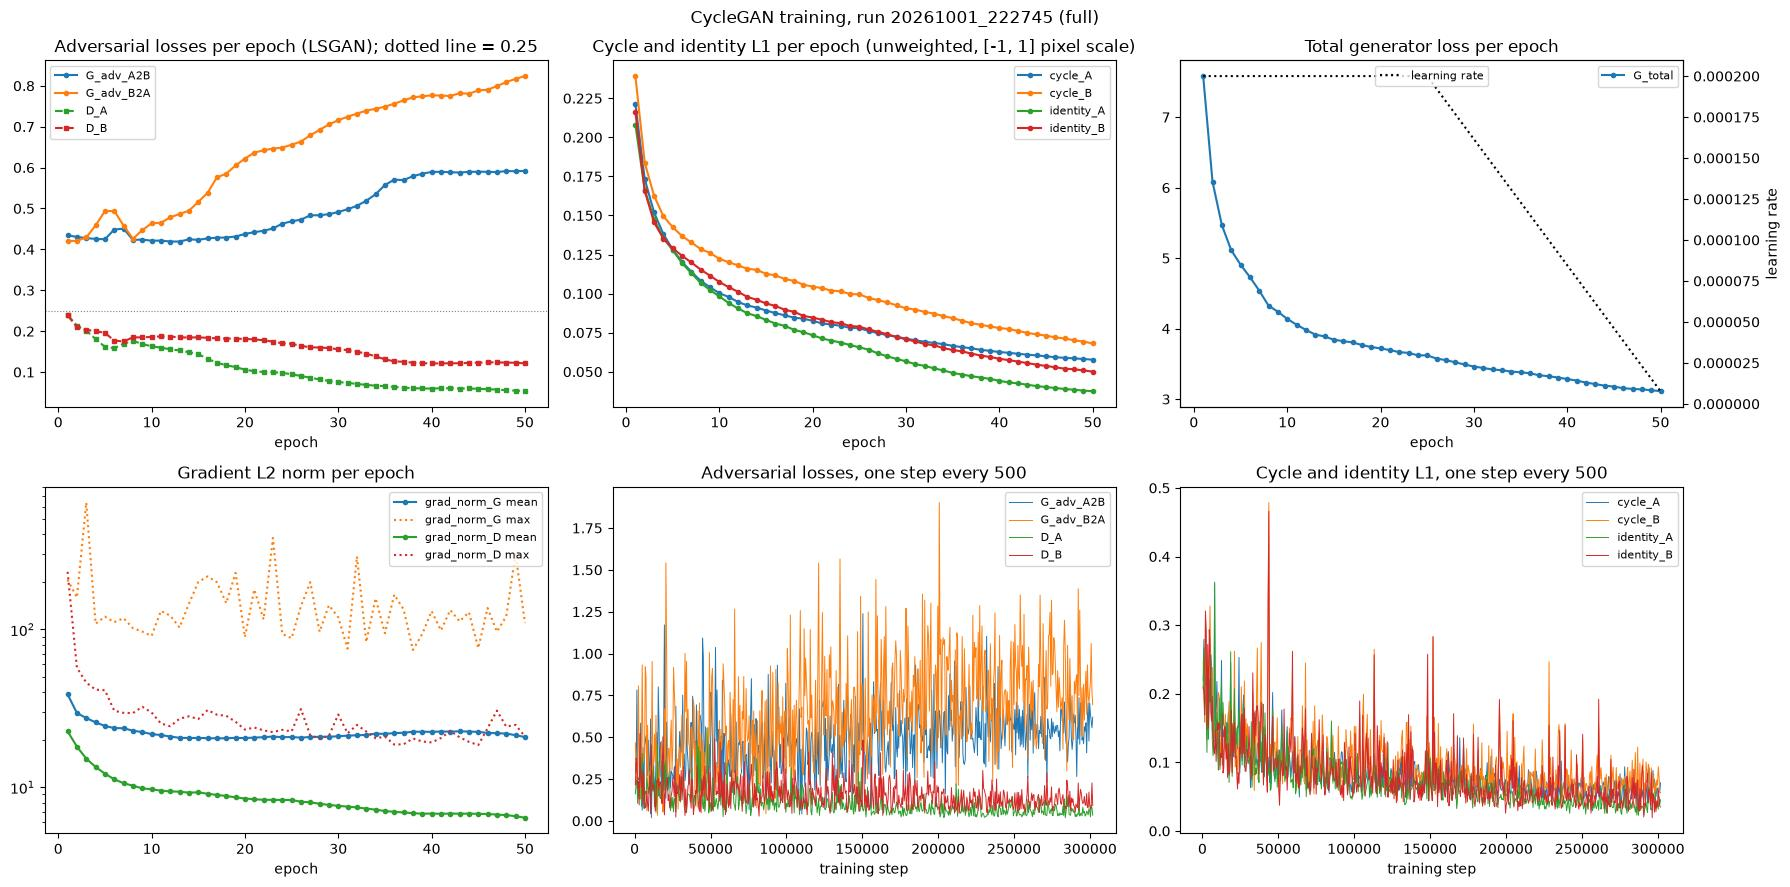

Non-finite (NaN/Inf) steps: 0
Training time: 375.1 min | 26.8 images/sec | peak GPU memory 9974 MB


In [11]:
with (RUN_DIR / 'train_history.csv').open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(epoch_history[0].keys()))
    writer.writeheader()
    writer.writerows(epoch_history)

epochs_axis = [h['epoch'] for h in epoch_history]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
ax = axes[0, 0]
for key in ['G_adv_A2B', 'G_adv_B2A']:
    ax.plot(epochs_axis, [h[key] for h in epoch_history], marker='o', ms=3, label=key)
for key in ['D_A', 'D_B']:
    ax.plot(epochs_axis, [h[key] for h in epoch_history], marker='s', ms=3, ls='--', label=key)
ax.axhline(0.25, color='gray', lw=0.8, ls=':')
ax.set(title='Adversarial losses per epoch (LSGAN); dotted line = 0.25', xlabel='epoch')
ax = axes[0, 1]
for key in ['cycle_A', 'cycle_B', 'identity_A', 'identity_B']:
    ax.plot(epochs_axis, [h[key] for h in epoch_history], marker='o', ms=3, label=key)
ax.set(title='Cycle and identity L1 per epoch (unweighted, [-1, 1] pixel scale)', xlabel='epoch')
ax = axes[0, 2]
ax.plot(epochs_axis, [h['G_total'] for h in epoch_history], marker='o', ms=3, label='G_total')
ax.set(title='Total generator loss per epoch', xlabel='epoch')
lr_ax = ax.twinx()
lr_ax.plot(epochs_axis, [h['learning_rate'] for h in epoch_history], color='black', ls=':', label='learning rate')
lr_ax.set_ylabel('learning rate')
lr_ax.legend(loc='upper center', fontsize=8)
ax = axes[1, 0]
for key in ['grad_norm_G', 'grad_norm_D']:
    ax.plot(epochs_axis, [h[key] for h in epoch_history], marker='o', ms=3, label=f'{key} mean')
    ax.plot(epochs_axis, [h[key + '_max'] for h in epoch_history], ls=':', label=f'{key} max')
ax.set(title='Gradient L2 norm per epoch', xlabel='epoch', yscale='log')
if step_history:
    steps_axis = [s['global_step'] for s in step_history]
    ax = axes[1, 1]
    for key in ['G_adv_A2B', 'G_adv_B2A', 'D_A', 'D_B']:
        ax.plot(steps_axis, [s[key] for s in step_history], lw=0.7, label=key)
    ax.set(title=f"Adversarial losses, one step every {CONFIG['log_every_steps']}", xlabel='training step')
    ax = axes[1, 2]
    for key in ['cycle_A', 'cycle_B', 'identity_A', 'identity_B']:
        ax.plot(steps_axis, [s[key] for s in step_history], lw=0.7, label=key)
    ax.set(title=f"Cycle and identity L1, one step every {CONFIG['log_every_steps']}", xlabel='training step')
for ax in axes.flat:
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8)
fig.suptitle(f'CycleGAN training, run {RUN_ID} ({RUN_KIND})')
fig.tight_layout()
fig.savefig(RUN_DIR / 'loss_curves.png', dpi=120)
plt.show()

print(f"Non-finite (NaN/Inf) steps: {nan_steps}")
print(f"Training time: {train_time_sec / 60:.1f} min | {TRAIN_STATS['train_images_per_sec']:.1f} images/sec "
      f"| peak GPU memory {TRAIN_STATS['peak_gpu_memory_allocated_mb_train']:.0f} MB")

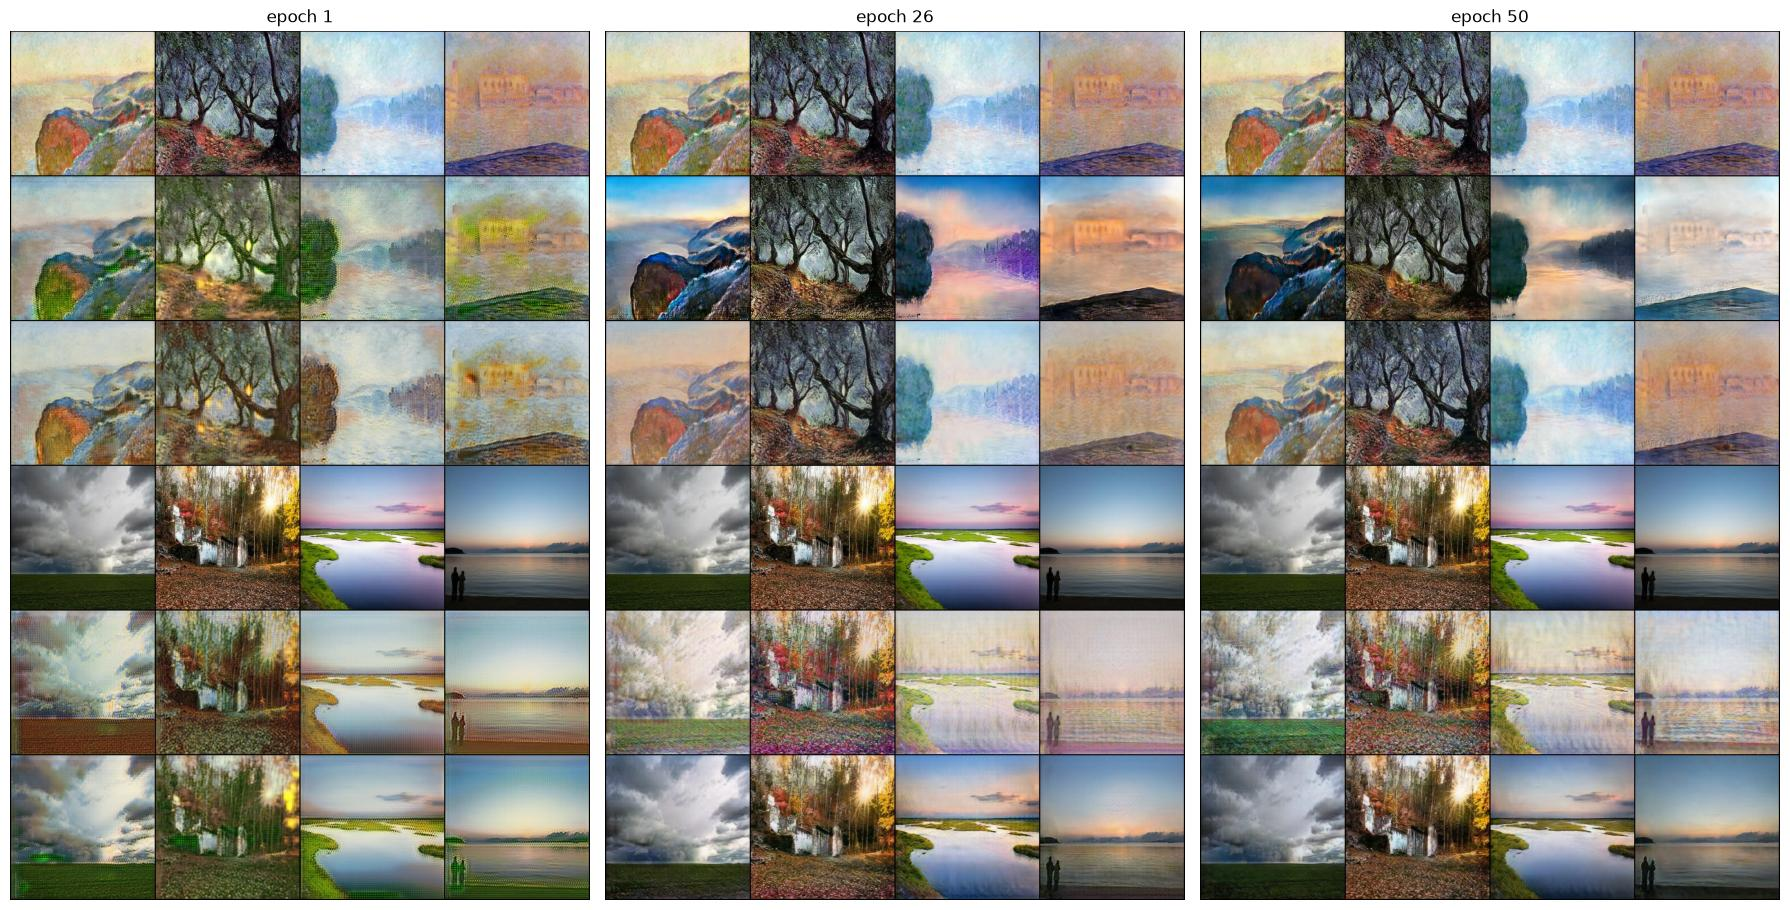

In [12]:
# Sample grids from the first, middle and last epoch.
# Rows: Monet | Monet->Photo | reconstructed Monet | Photo | Photo->Monet | reconstructed Photo
shown = sorted({epoch_history[0]['epoch'], epoch_history[len(epoch_history) // 2]['epoch'], epoch_history[-1]['epoch']})
shown = [e for e in shown if (RUN_DIR / 'samples' / f'epoch{e:03d}.jpg').exists()]
fig, axes = plt.subplots(1, len(shown), figsize=(6 * len(shown), 9), squeeze=False)
for ax, e in zip(axes[0], shown):
    ax.imshow(Image.open(RUN_DIR / 'samples' / f'epoch{e:03d}.jpg'))
    ax.set_title(f'epoch {e}')
    ax.axis('off')
fig.tight_layout()
plt.show()

## 3.2 Evaluation and Analysis

All metrics are computed in both directions with the final-epoch generators:

- **A2B (Monet -> Photo):** the 300 Monet paintings are translated and compared with the held-out real photos.
- **B2A (Photo -> Monet):** the held-out photos are translated and compared with the 300 real Monet paintings.

The pretrained InceptionV3 and AlexNet-LPIPS networks below only measure the images. They never see a
gradient and never change a generated image.

In [13]:
import lpips
from pytorch_fid.inception import InceptionV3
from scipy import linalg

for net in NETS.values():
    net.eval()
if device.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()

inception = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]], resize_input=True, normalize_input=True).to(device).eval()
lpips_alex = lpips.LPIPS(net='alex', verbose=False).to(device).eval()

@torch.no_grad()
def inception_features(images):
    """2048-d pool features of the standard FID InceptionV3. `images` are in [-1, 1]."""
    return inception((images + 1) / 2)[0].flatten(1).double().cpu().numpy()

@torch.no_grad()
def translate_set(images_u8, files, G_forward, G_back, save_dir):
    """Translate every image, reconstruct it, save the translation, and collect per-image scores."""
    save_dir.mkdir(parents=True, exist_ok=True)
    for old in save_dir.glob('*.jpg'):
        old.unlink()
    out = {k: [] for k in ['translated', 'features_in', 'features_out', 'cycle_l1', 'identity_l1',
                           'translation_l1', 'lpips_translation', 'lpips_reconstruction']}
    G_forward(to_float(images_u8[:CONFIG['eval_batch_size']].to(device)))   # warm-up, so one-off setup is not timed
    generation_time = 0.0
    for start in range(0, len(images_u8), CONFIG['eval_batch_size']):
        x = to_float(images_u8[start:start + CONFIG['eval_batch_size']].to(device))
        sync()
        t0 = time.perf_counter()
        y = G_forward(x)
        sync()
        generation_time += time.perf_counter() - t0
        reconstruction = G_back(y)
        same_domain = G_back(x)                      # x is already in G_back's output domain
        y_u8 = to_uint8(y).cpu()
        out['translated'].append(y_u8)
        out['features_in'].append(inception_features(x))
        out['features_out'].append(inception_features(y))
        # L1 distances are divided by 2 to report them on the [0, 1] pixel scale.
        out['cycle_l1'].append(((reconstruction - x).abs().mean((1, 2, 3)) / 2).cpu())
        out['identity_l1'].append(((same_domain - x).abs().mean((1, 2, 3)) / 2).cpu())
        out['translation_l1'].append(((y - x).abs().mean((1, 2, 3)) / 2).cpu())
        out['lpips_translation'].append(lpips_alex(x, y).flatten().cpu())
        out['lpips_reconstruction'].append(lpips_alex(x, reconstruction).flatten().cpu())
        for image, path in zip(y_u8, files[start:start + len(y_u8)]):
            Image.fromarray(image.permute(1, 2, 0).numpy()).save(save_dir / f'{path.stem}.jpg', quality=95)
    result = {k: (np.concatenate(v) if k.startswith('features') else torch.cat(v).numpy()) for k, v in out.items() if k != 'translated'}
    result['translated'] = torch.cat(out['translated'])      # uint8 images, kept for the figures below
    f_in, f_out = result['features_in'], result['features_out']
    result['content_cosine'] = (f_in * f_out).sum(1) / (np.linalg.norm(f_in, axis=1) * np.linalg.norm(f_out, axis=1) + 1e-8)
    result['generation_images_per_sec'] = len(images_u8) / generation_time
    return result

RESULTS = {
    'A2B': translate_set(eval_monet, monet_files, G_A2B, G_B2A, PRED_ROOT / 'pred_A2B'),
    'B2A': translate_set(eval_photo, photo_eval_files, G_B2A, G_A2B, PRED_ROOT / 'pred_B2A'),
}
EVAL_FILES = {'A2B': monet_files, 'B2A': photo_eval_files}
EVAL_IMAGES = {'A2B': eval_monet, 'B2A': eval_photo}
# Real reference features of the target domain: real photos for A2B, real Monet paintings for B2A.
REFERENCE = {'A2B': RESULTS['B2A']['features_in'], 'B2A': RESULTS['A2B']['features_in']}
log(f"translated: A2B {len(eval_monet)} images -> {rel(PRED_ROOT / 'pred_A2B')}, "
    f"B2A {len(eval_photo)} images -> {rel(PRED_ROOT / 'pred_B2A')}")

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[2026-10-02 04:43:50] translated: A2B 300 images -> task3_gan/member_anushka/outputs/pred_A2B, B2A 1000 images -> task3_gan/member_anushka/outputs/pred_B2A


In [14]:
def frechet_inception_distance(features_1, features_2):
    mu_1, mu_2 = features_1.mean(0), features_2.mean(0)
    sigma_1, sigma_2 = np.cov(features_1, rowvar=False), np.cov(features_2, rowvar=False)
    cov_sqrt, _ = linalg.sqrtm(sigma_1.dot(sigma_2), disp=False)
    if not np.isfinite(cov_sqrt).all():
        offset = np.eye(sigma_1.shape[0]) * 1e-6
        cov_sqrt = linalg.sqrtm((sigma_1 + offset).dot(sigma_2 + offset))
    cov_sqrt = cov_sqrt.real
    return float(((mu_1 - mu_2) ** 2).sum() + np.trace(sigma_1) + np.trace(sigma_2) - 2 * np.trace(cov_sqrt))

def kernel_inception_distance(features_1, features_2, n_subsets, subset_size, seed=0):
    """Unbiased MMD^2 with the cubic polynomial kernel k(x, y) = (x.y / d + 1)^3, averaged over random subsets."""
    rng = np.random.default_rng(seed)
    d = features_1.shape[1]
    m = min(subset_size, len(features_1), len(features_2))
    values = []
    for _ in range(n_subsets):
        x = features_1[rng.choice(len(features_1), m, replace=False)]
        y = features_2[rng.choice(len(features_2), m, replace=False)]
        k_xx, k_yy, k_xy = (x @ x.T / d + 1) ** 3, (y @ y.T / d + 1) ** 3, (x @ y.T / d + 1) ** 3
        values.append((k_xx.sum() - np.trace(k_xx)) / (m * (m - 1))
                      + (k_yy.sum() - np.trace(k_yy)) / (m * (m - 1)) - 2 * k_xy.mean())
    return float(np.mean(values)), float(np.std(values))

def pairwise_distances(a, b):
    return np.sqrt(np.maximum((a ** 2).sum(1)[:, None] + (b ** 2).sum(1)[None] - 2 * a @ b.T, 0))

def precision_recall_density_coverage(real, fake, k):
    """Precision/recall (Kynkaanniemi et al., 2019) and density/coverage (Naeem et al., 2020)
    from k-nearest-neighbour balls in Inception feature space."""
    real_radius = np.sort(pairwise_distances(real, real), axis=1)[:, k]    # column 0 is the point itself
    fake_radius = np.sort(pairwise_distances(fake, fake), axis=1)[:, k]
    distance = pairwise_distances(real, fake)
    return {
        'precision': float((distance < real_radius[:, None]).any(0).mean()),   # fakes inside the real manifold
        'recall': float((distance < fake_radius[None, :]).any(1).mean()),      # reals inside the fake manifold
        'density': float((distance < real_radius[:, None]).sum(0).mean() / k),
        'coverage': float((distance.min(1) < real_radius).mean()),
    }

METRIC_ROWS = []
def add_metric(direction, metric, value):
    METRIC_ROWS.append({'direction': direction, 'metric': metric, 'value': value})

for direction, r in RESULTS.items():
    kid_mean, kid_std = kernel_inception_distance(r['features_out'], REFERENCE[direction],
                                                  CONFIG['kid_subsets'], CONFIG['kid_subset_size'])
    values = {
        'FID': frechet_inception_distance(r['features_out'], REFERENCE[direction]),
        # FID of the untranslated inputs against the target domain: the "do nothing" reference point.
        'FID_untranslated_input_baseline': frechet_inception_distance(r['features_in'], REFERENCE[direction]),
        'KID_mean': kid_mean, 'KID_std': kid_std,
        **{f'gen_{k}': v for k, v in precision_recall_density_coverage(REFERENCE[direction], r['features_out'], CONFIG['prdc_k']).items()},
        'cycle_reconstruction_L1': float(r['cycle_l1'].mean()),
        'identity_L1': float(r['identity_l1'].mean()),
        'LPIPS_input_vs_translation': float(r['lpips_translation'].mean()),
        'LPIPS_input_vs_reconstruction': float(r['lpips_reconstruction'].mean()),
        'content_cosine_input_vs_translation': float(r['content_cosine'].mean()),
        'inference_images_per_sec': r['generation_images_per_sec'],
        'n_translated': len(r['features_out']), 'n_reference': len(REFERENCE[direction]),
    }
    for metric, value in values.items():
        add_metric(direction, metric, value)
    log(f'eval {direction}: ' + ' '.join(f'{k}={v:.4f}' if isinstance(v, float) else f'{k}={v}' for k, v in values.items()))

with (RUN_DIR / 'per_image_scores.csv').open('w', newline='') as f:
    writer = csv.writer(f)
    score_keys = ['cycle_l1', 'identity_l1', 'translation_l1', 'lpips_translation', 'lpips_reconstruction', 'content_cosine']
    writer.writerow(['direction', 'file'] + score_keys)
    for direction, r in RESULTS.items():
        for i, path in enumerate(EVAL_FILES[direction]):
            writer.writerow([direction, path.name] + [f'{float(r[k][i]):.6f}' for k in score_keys])

/tmp/ipykernel_7/1075519994.py:4: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  cov_sqrt, _ = linalg.sqrtm(sigma_1.dot(sigma_2), disp=False)


[2026-10-02 04:44:05] eval A2B: FID=81.1600 FID_untranslated_input_baseline=122.7093 KID_mean=0.0163 KID_std=0.0007 gen_precision=0.7400 gen_recall=0.4690 gen_density=0.9147 gen_coverage=0.5540 cycle_reconstruction_L1=0.0345 identity_L1=0.0253 LPIPS_input_vs_translation=0.3378 LPIPS_input_vs_reconstruction=0.2326 content_cosine_input_vs_translation=0.7923 inference_images_per_sec=327.4222 n_translated=300 n_reference=1000


[2026-10-02 04:44:18] eval B2A: FID=88.5785 FID_untranslated_input_baseline=122.7093 KID_mean=0.0143 KID_std=0.0010 gen_precision=0.5040 gen_recall=0.6433 gen_density=0.4476 gen_coverage=0.8967 cycle_reconstruction_L1=0.0467 identity_L1=0.0348 LPIPS_input_vs_translation=0.3845 LPIPS_input_vs_reconstruction=0.1743 content_cosine_input_vs_translation=0.7407 inference_images_per_sec=332.9897 n_translated=1000 n_reference=300


### Convergence: FID at every saved checkpoint

The generators stored in each checkpoint translate the same evaluation images, and the FID against the
target domain is computed for each one. The adversarial losses do not say whether the images are getting
better, so this curve is the direct view of how translation quality moved during training.

/tmp/ipykernel_7/1075519994.py:4: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  cov_sqrt, _ = linalg.sqrtm(sigma_1.dot(sigma_2), disp=False)


[2026-10-02 04:44:43] checkpoint FID epoch 5: A2B=102.989 B2A=107.706


[2026-10-02 04:45:03] checkpoint FID epoch 10: A2B=100.941 B2A=103.298


[2026-10-02 04:45:22] checkpoint FID epoch 15: A2B=95.364 B2A=103.900


[2026-10-02 04:45:42] checkpoint FID epoch 20: A2B=88.023 B2A=94.301


...

[2026-10-02 04:46:21] checkpoint FID epoch 30: A2B=89.951 B2A=90.949


[2026-10-02 04:46:41] checkpoint FID epoch 35: A2B=83.327 B2A=98.200


[2026-10-02 04:47:00] checkpoint FID epoch 40: A2B=83.645 B2A=92.124


[2026-10-02 04:47:19] checkpoint FID epoch 45: A2B=82.431 B2A=89.861


[2026-10-02 04:47:39] checkpoint FID epoch 50: A2B=81.160 B2A=88.578


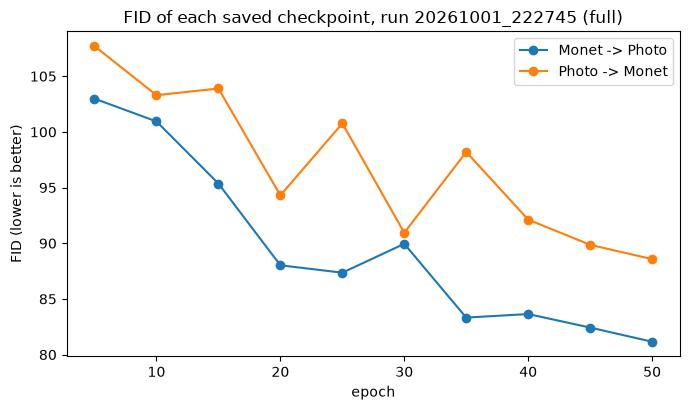

In [15]:
@torch.no_grad()
def translated_features(images_u8, G):
    features = []
    for start in range(0, len(images_u8), CONFIG['eval_batch_size']):
        x = to_float(images_u8[start:start + CONFIG['eval_batch_size']].to(device))
        features.append(inception_features(G(x)))
    return np.concatenate(features)

probe_G = ResNetGenerator(CONFIG['generator_base_channels'], CONFIG['generator_residual_blocks']).to(device).eval()
checkpoint_fid = []
for path in sorted(RUN_CHECKPOINT_DIR.glob(f'cyclegan_{RUN_ID}_epoch*.pt')):
    state = torch.load(path, map_location=device, weights_only=False)
    row = {'epoch': state['epoch']}
    for direction, name in [('A2B', 'G_A2B'), ('B2A', 'G_B2A')]:
        probe_G.load_state_dict(state['nets'][name])
        row[f'FID_{direction}'] = frechet_inception_distance(translated_features(EVAL_IMAGES[direction], probe_G), REFERENCE[direction])
        add_metric(direction, f"FID_checkpoint_epoch{state['epoch']:03d}", row[f'FID_{direction}'])
    checkpoint_fid.append(row)
    log(f"checkpoint FID epoch {row['epoch']}: A2B={row['FID_A2B']:.3f} B2A={row['FID_B2A']:.3f}")
    del state
del probe_G

fig, ax = plt.subplots(figsize=(7, 4.2))
for direction, label in [('A2B', 'Monet -> Photo'), ('B2A', 'Photo -> Monet')]:
    ax.plot([r['epoch'] for r in checkpoint_fid], [r[f'FID_{direction}'] for r in checkpoint_fid], marker='o', label=label)
ax.set(title=f'FID of each saved checkpoint, run {RUN_ID} ({RUN_KIND})', xlabel='epoch', ylabel='FID (lower is better)')
ax.legend()
fig.tight_layout()
fig.savefig(RUN_DIR / 'fid_by_checkpoint.png', dpi=120)
plt.show()

### Visual quality of the translations

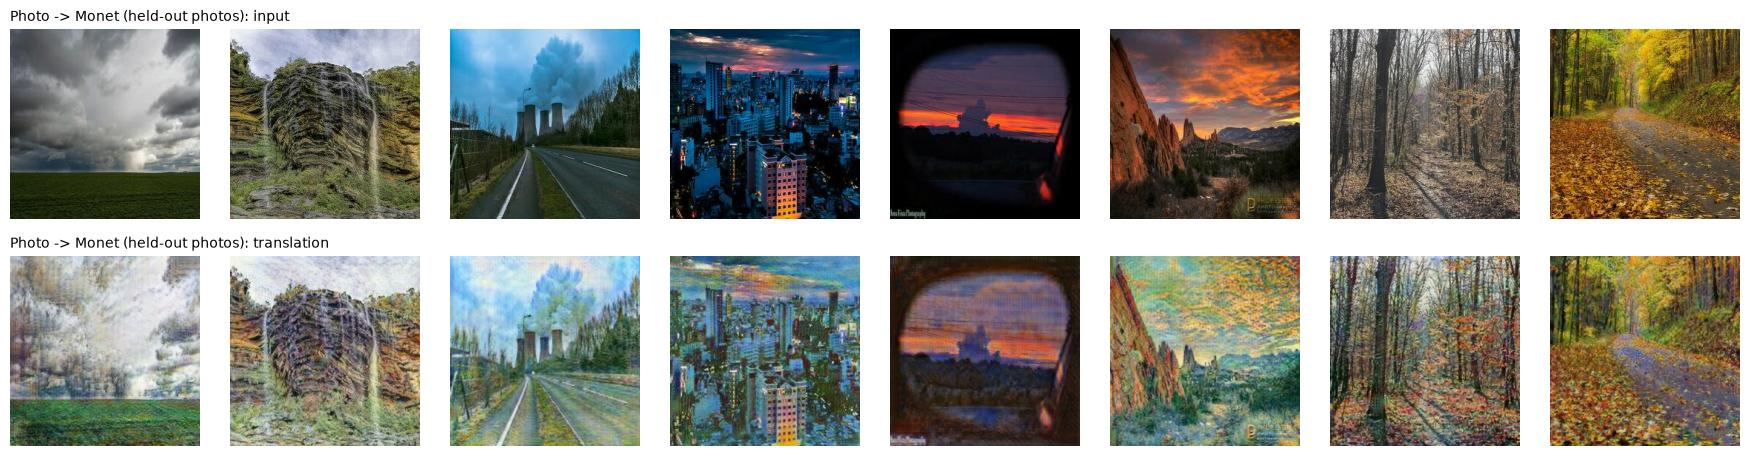

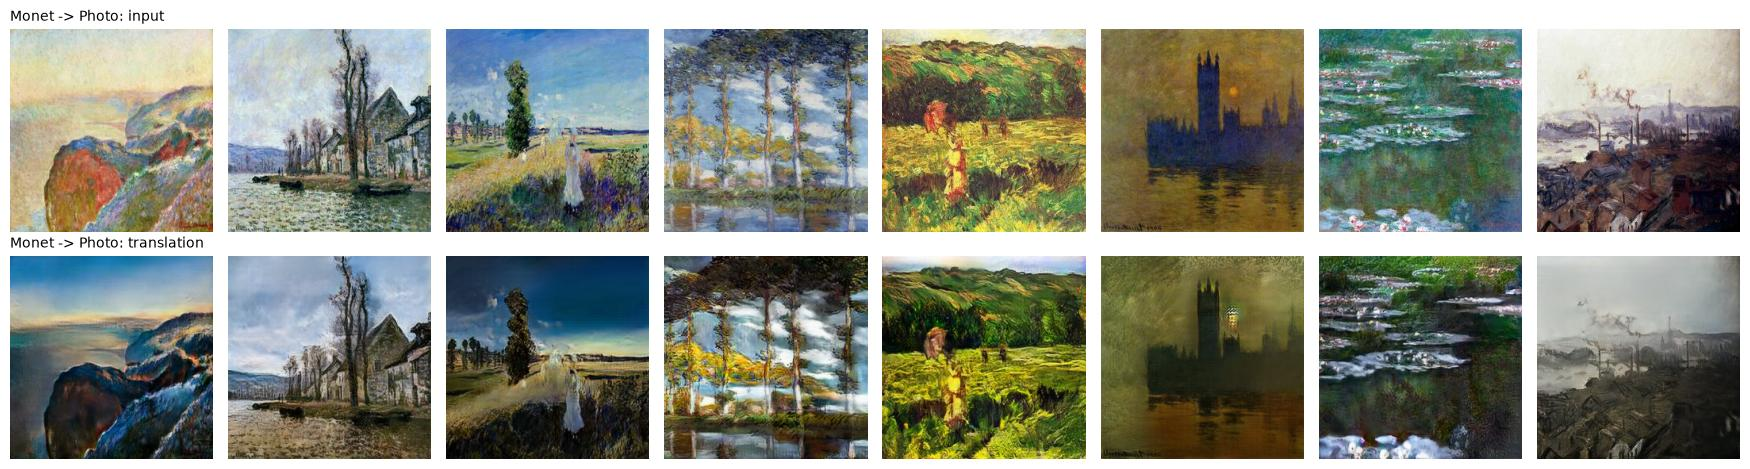

In [16]:
def show_translations(direction, title, n=8):
    images, translated = EVAL_IMAGES[direction], RESULTS[direction]['translated']
    picks = np.linspace(0, len(images) - 1, n).astype(int)        # evenly spaced, not hand-picked
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 4.8))
    show_row(axes[0], images[picks], f'{title}: input')
    show_row(axes[1], translated[picks], f'{title}: translation')
    fig.tight_layout()
    fig.savefig(RUN_DIR / f'translations_{direction}.jpg', dpi=110)
    plt.show()

show_translations('B2A', 'Photo -> Monet (held-out photos)')
show_translations('A2B', 'Monet -> Photo')

### Cycle-consistency check

If the cycle constraint is implemented correctly, `G_B2A(G_A2B(a))` returns to `a` and `G_A2B(G_B2A(b))`
returns to `b`. Three numbers are compared for each direction (mean L1 on the [0, 1] pixel scale):

1. **Reconstruction:** an image against its own round-trip reconstruction.
2. **Translation:** an image against its translation. The translation should change the image, so this
   should be clearly larger than (1).
3. **Mismatched:** an image against the reconstruction of a different image. If (1) is far below (3), the
   round trip keeps the content of the specific input and is not just producing a generic image.

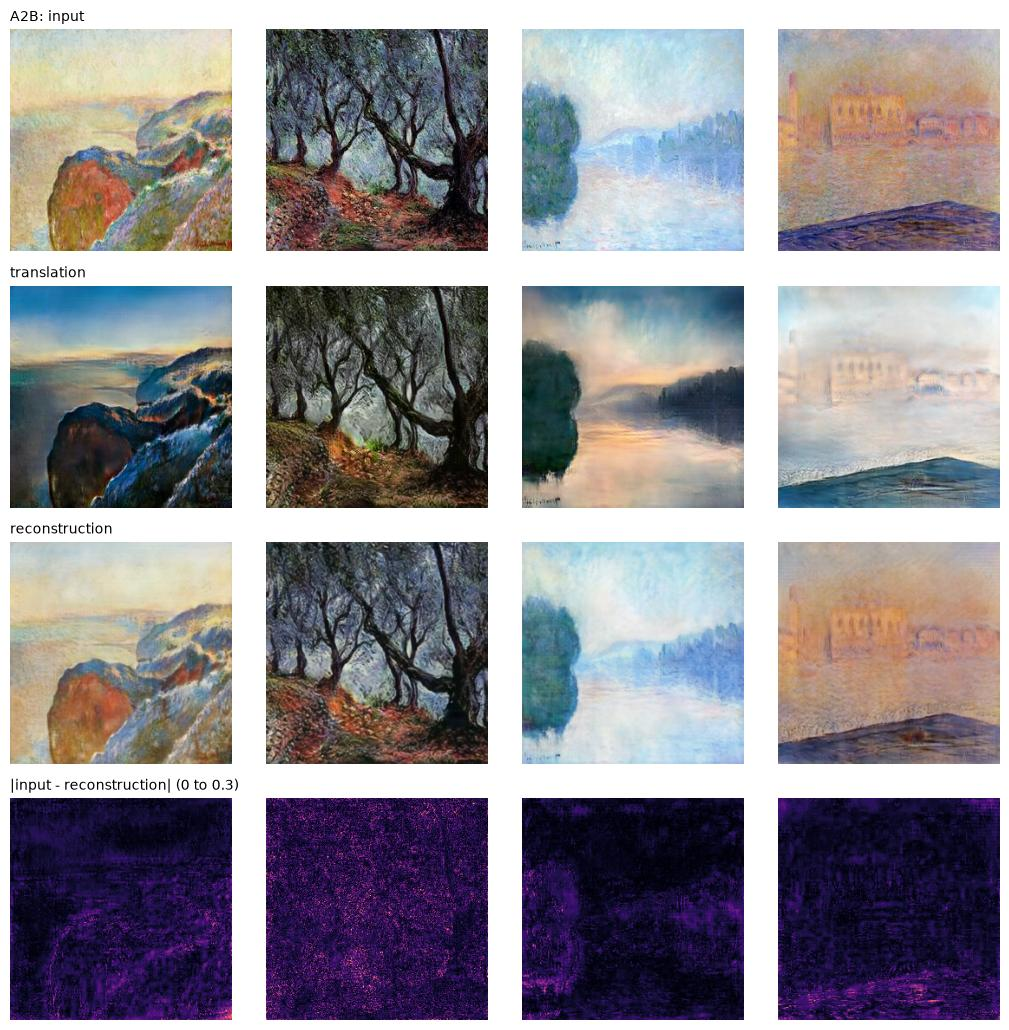

A2B on 64 images: reconstruction L1 = 0.0344 | translation L1 = 0.1364 | mismatched reconstruction L1 = 0.2400


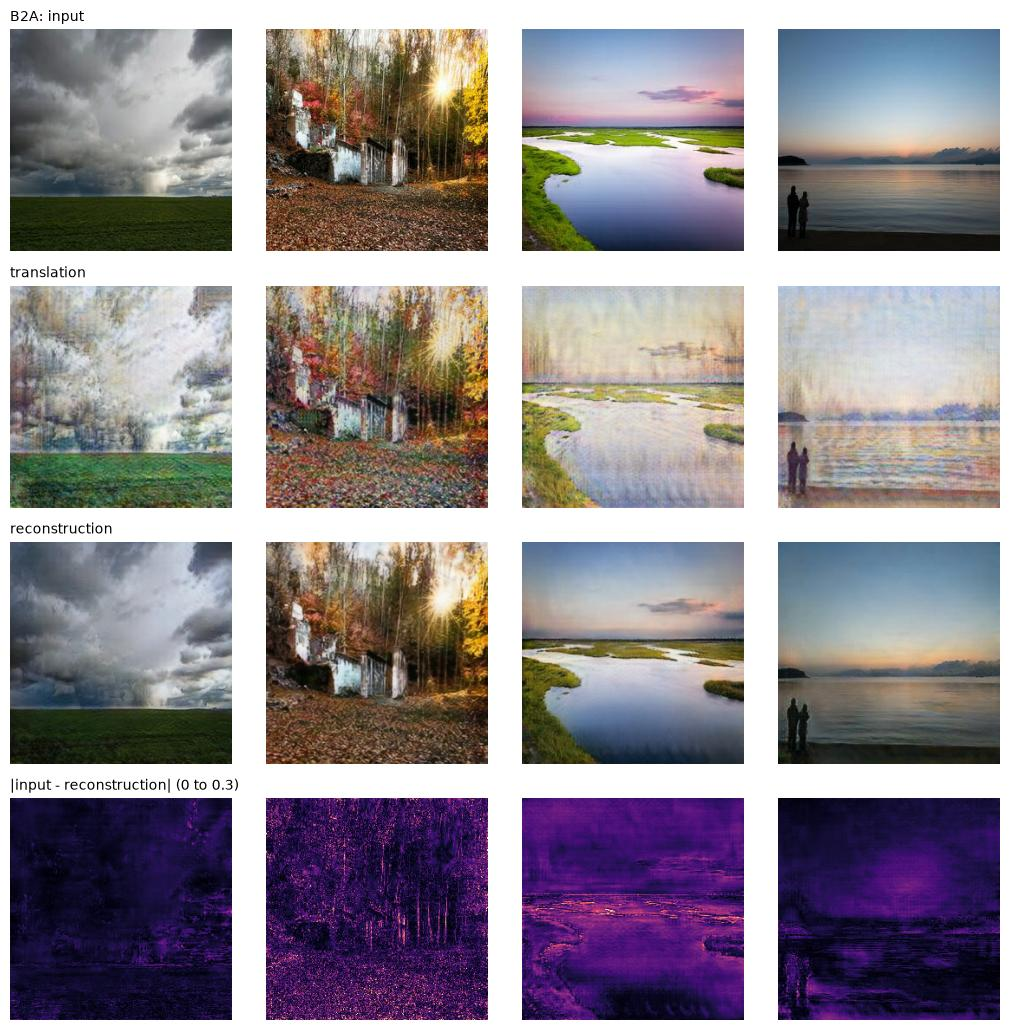

B2A on 64 images: reconstruction L1 = 0.0448 | translation L1 = 0.1536 | mismatched reconstruction L1 = 0.2685


In [17]:
@torch.no_grad()
def cycle_check(direction, G_forward, G_back, n=4):
    images = EVAL_IMAGES[direction]
    x = to_float(images[:min(64, len(images))].to(device))
    y = G_forward(x)
    reconstruction = G_back(y)
    own = ((reconstruction - x).abs().mean() / 2).item()
    mismatched = ((reconstruction.roll(1, 0) - x).abs().mean() / 2).item()
    translation = ((y - x).abs().mean() / 2).item()
    error_map = (reconstruction - x).abs().mean(1) / 2
    fig, axes = plt.subplots(4, n, figsize=(2.6 * n, 10.4))
    show_row(axes[0], to_uint8(x[:n]).cpu(), f'{direction}: input')
    show_row(axes[1], to_uint8(y[:n]).cpu(), 'translation')
    show_row(axes[2], to_uint8(reconstruction[:n]).cpu(), 'reconstruction')
    for ax, err in zip(axes[3], error_map[:n].cpu()):
        ax.imshow(err.numpy(), cmap='magma', vmin=0, vmax=0.3)
        ax.axis('off')
    axes[3][0].set_title('|input - reconstruction| (0 to 0.3)', loc='left', fontsize=10)
    fig.tight_layout()
    fig.savefig(RUN_DIR / f'cycle_check_{direction}.jpg', dpi=110)
    plt.show()
    print(f'{direction} on {len(x)} images: reconstruction L1 = {own:.4f} | translation L1 = {translation:.4f} '
          f'| mismatched reconstruction L1 = {mismatched:.4f}')
    add_metric(direction, 'cycle_check_mismatched_reconstruction_L1', mismatched)
    add_metric(direction, 'cycle_check_translation_L1', translation)

cycle_check('A2B', G_A2B, G_B2A)
cycle_check('B2A', G_B2A, G_A2B)

### Candidate failure cases

The images with the worst scores, chosen by the numbers and not by eye: highest cycle-reconstruction L1
(content not recoverable) and lowest content cosine (content changed most). These are the starting point
for `failure_analysis.md`.

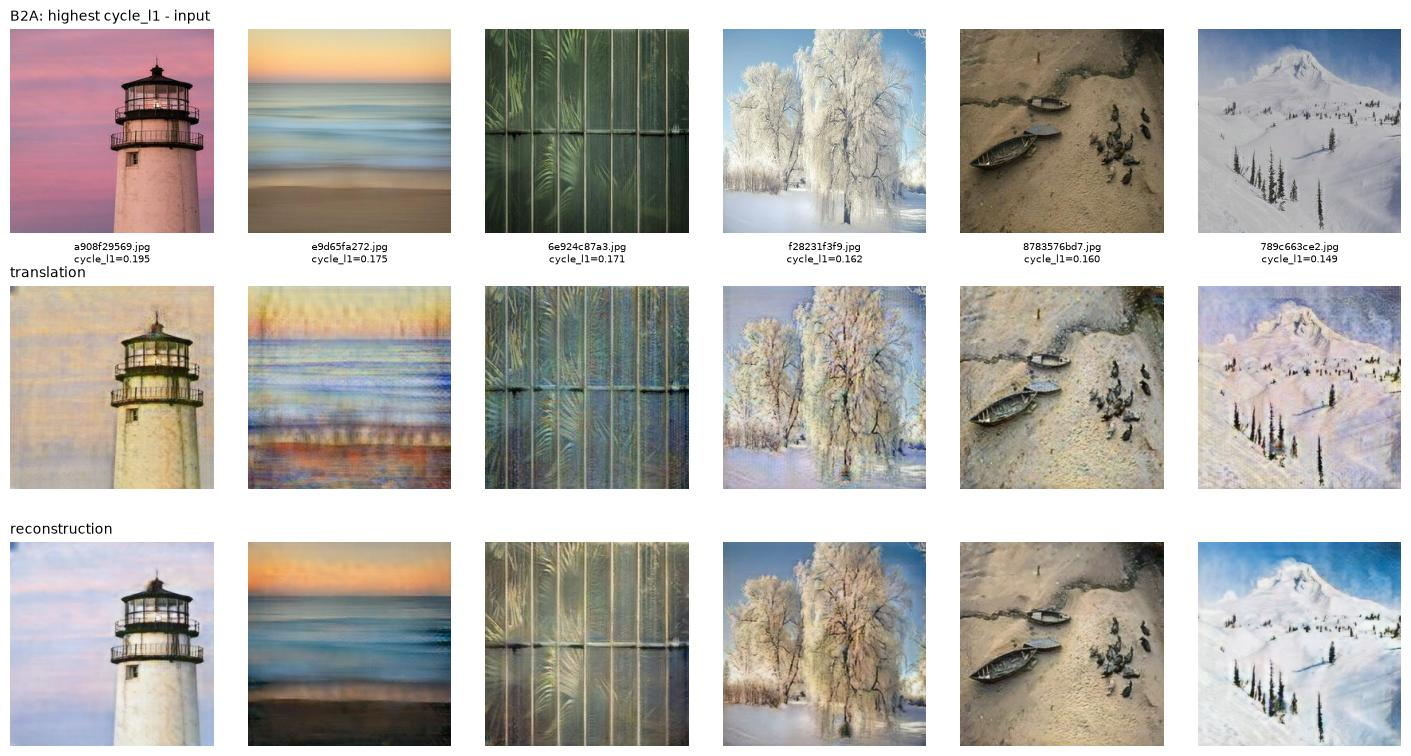

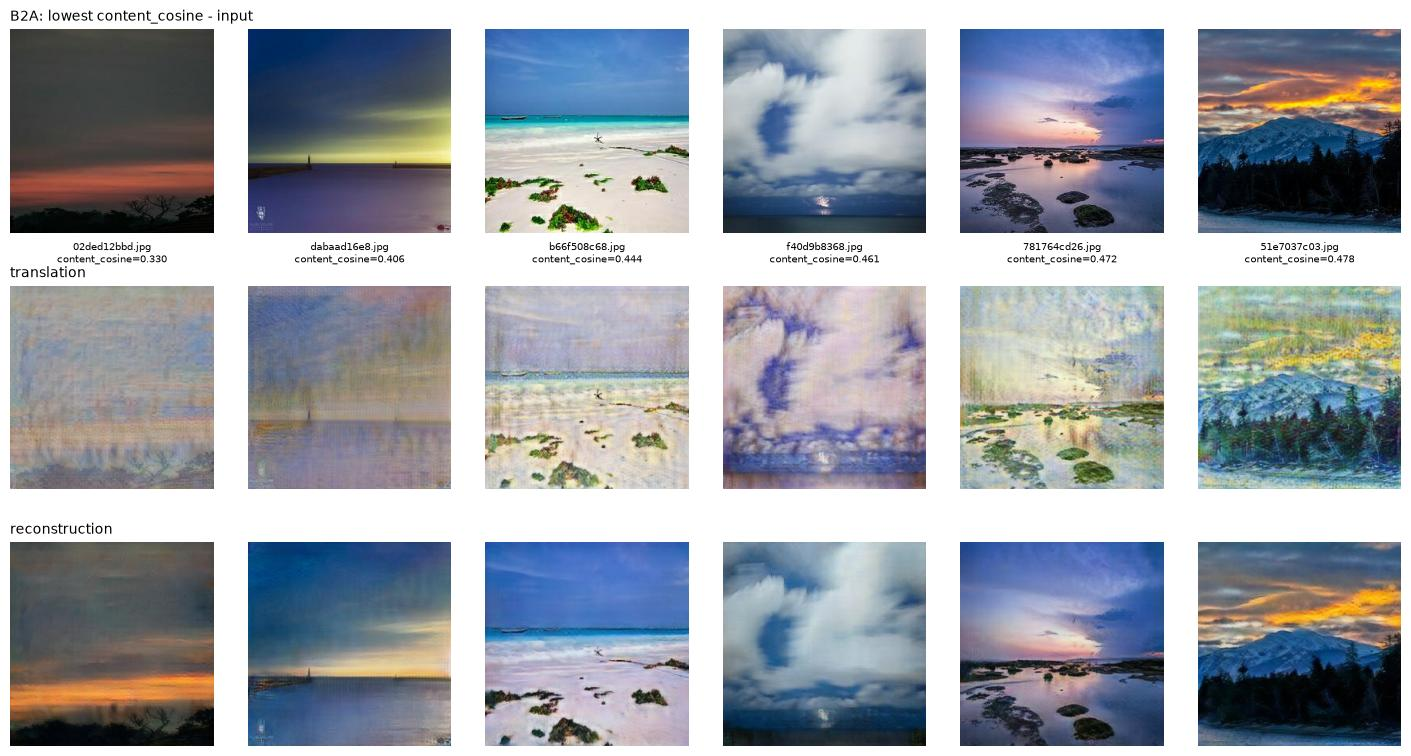

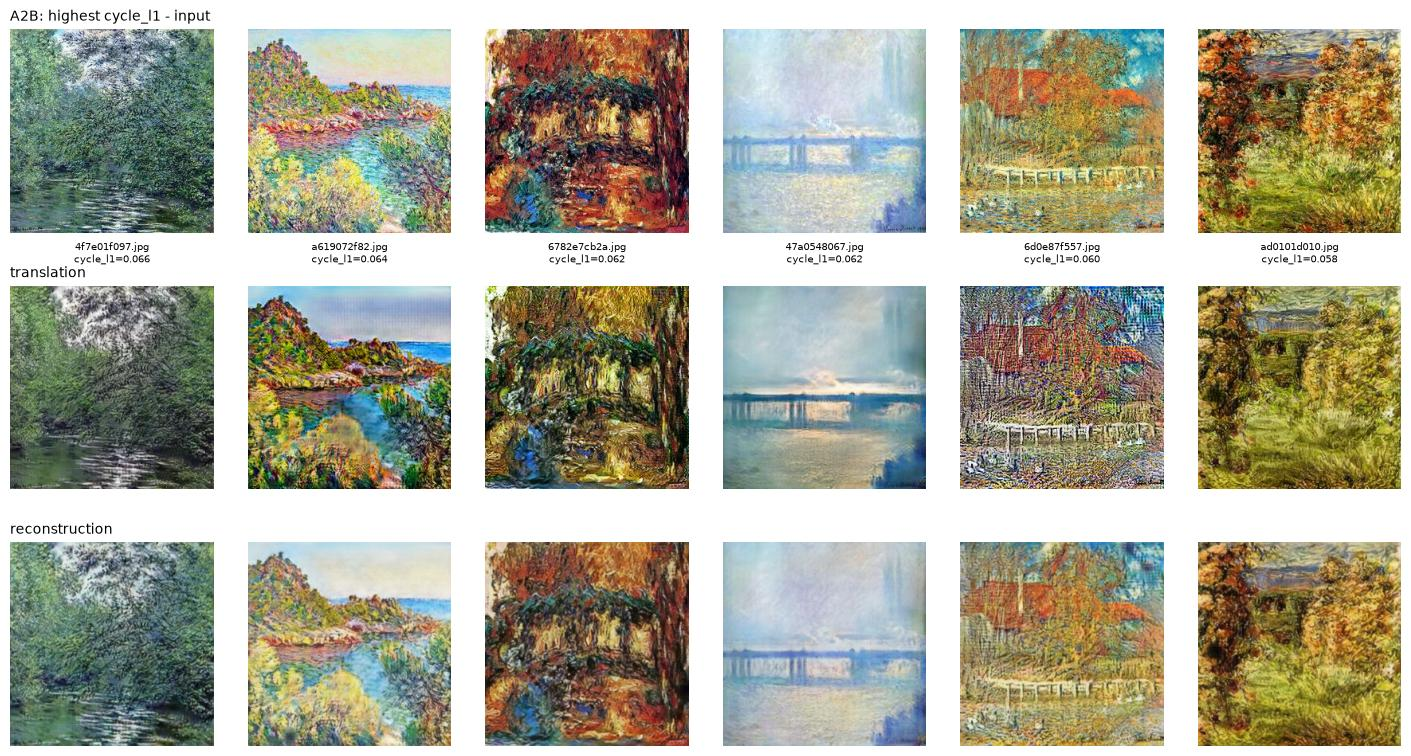

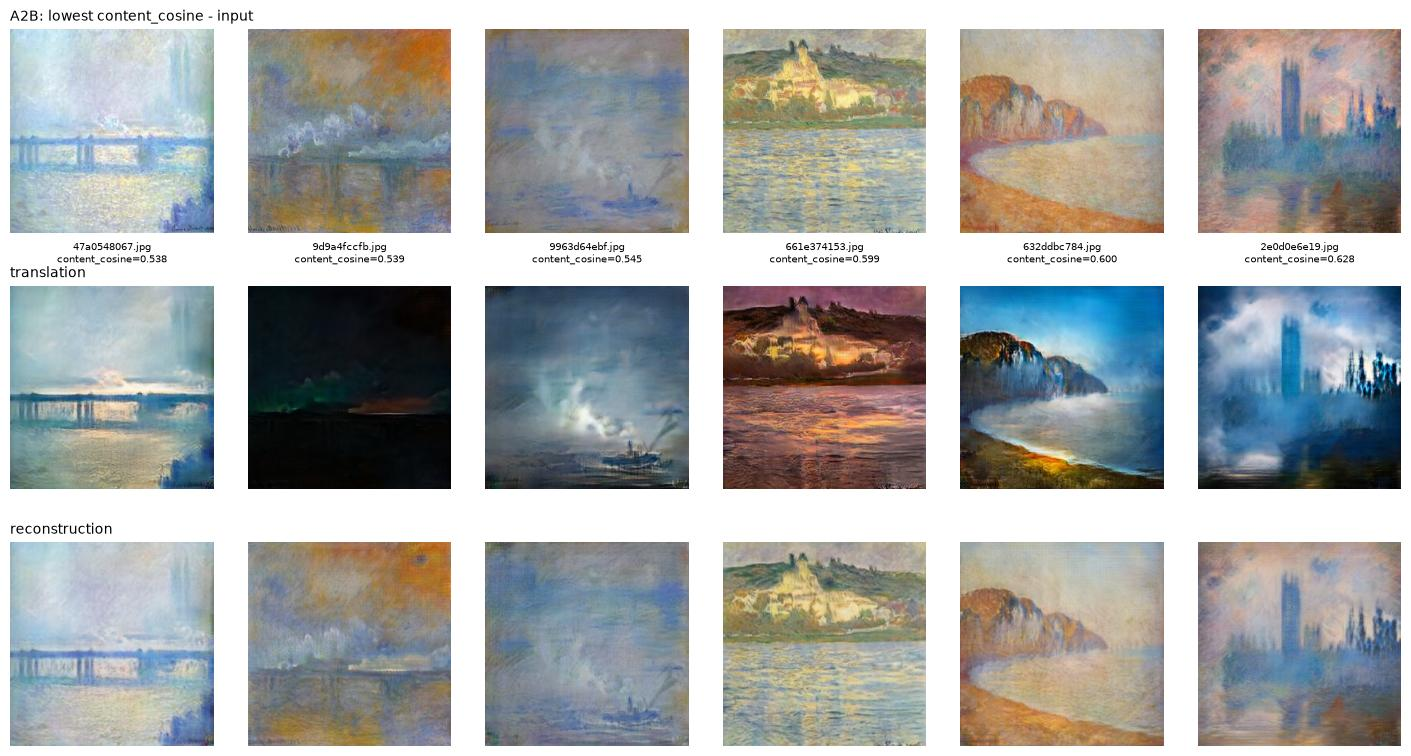

In [18]:
@torch.no_grad()
def show_worst(direction, G_back, score_key, largest, n=6):
    scores = RESULTS[direction][score_key]
    order = np.argsort(scores)
    picks = order[::-1][:n].copy() if largest else order[:n].copy()
    images, translated = EVAL_IMAGES[direction], RESULTS[direction]['translated']
    reconstruction = to_uint8(G_back(to_float(translated[picks].to(device)))).cpu()
    fig, axes = plt.subplots(3, n, figsize=(2.4 * n, 7.6))
    show_row(axes[0], images[picks], f"{direction}: {'highest' if largest else 'lowest'} {score_key} - input")
    show_row(axes[1], translated[picks], 'translation')
    show_row(axes[2], reconstruction, 'reconstruction')
    for ax, i in zip(axes[0], picks):
        ax.text(0.5, -0.04, f'{EVAL_FILES[direction][i].name}\n{score_key}={scores[i]:.3f}', transform=ax.transAxes,
                ha='center', va='top', fontsize=7)
    fig.tight_layout()
    fig.savefig(RUN_DIR / f'failure_candidates_{direction}_{score_key}.jpg', dpi=110)
    plt.show()

show_worst('B2A', G_A2B, 'cycle_l1', largest=True)
show_worst('B2A', G_A2B, 'content_cosine', largest=False)
show_worst('A2B', G_B2A, 'cycle_l1', largest=True)
show_worst('A2B', G_B2A, 'content_cosine', largest=False)

### Course evaluation script: FID and MiFID for the Kaggle submission

`evaluate_local.py` is the course script. It reads the saved `pred_A2B` / `pred_B2A` images and the real
image folders and writes `submission.csv`.

In [19]:
EVAL_PEAK_GPU_MB = torch.cuda.max_memory_allocated() / 1024**2 if device.type == 'cuda' else 0.0
del inception, lpips_alex
if device.type == 'cuda':
    torch.cuda.empty_cache()

SUBMISSION_FILE = REPORT_DIR / 'submission.csv'
course_run = subprocess.run(
    [sys.executable, str(MEMBER_DIR / 'evaluate_local.py'),
     '--pred-a2b', str(PRED_ROOT / 'pred_A2B'), '--pred-b2a', str(PRED_ROOT / 'pred_B2A'),
     '--out', str(SUBMISSION_FILE)],
    capture_output=True, text=True)
print(course_run.stdout)
if course_run.returncode != 0:
    print(course_run.stderr)
    raise RuntimeError('evaluate_local.py failed')
course_values = dict(item.split('=') for item in course_run.stdout.strip().splitlines()[-1].split()[1:])
add_metric('A2B', 'course_script_FID', float(course_values['fid_A2B']))
add_metric('A2B', 'course_script_MiFID', float(course_values['mifid_A2B']))
add_metric('B2A', 'course_script_FID', float(course_values['fid_B2A']))
add_metric('B2A', 'course_script_MiFID', float(course_values['mifid_B2A']))
with SUBMISSION_FILE.open() as f:
    submission = next(csv.DictReader(f))
add_metric('both', 'submission_FID', float(submission['FID']))
add_metric('both', 'submission_MiFID', float(submission['MiFID']))
log(f"course script: {course_run.stdout.strip().splitlines()[-1]} -> {rel(SUBMISSION_FILE)}")

Device: cuda

Counts (after N_EVAL cap):
Real Monet: 300  | Gen Monet (B2A): 300
Real Photo: 300  | Gen Photo (A2B): 300

 Evaluating Photo -> Monet (B2A) 
[Photo->Monet] FID=95.023  MiFID=0.4045

 Evaluating Monet -> Photo (A2B) 
[Monet->Photo] FID=98.749  MiFID=0.4150
   ID        FID    MiFID
0   1  96.886115  0.40971
DIRECTIONAL fid_A2B=98.74896046846882 mifid_A2B=0.4149603843688965 fid_B2A=95.0232690030082 mifid_B2A=0.4044598340988159

[2026-10-02 04:48:12] course script: DIRECTIONAL fid_A2B=98.74896046846882 mifid_A2B=0.4149603843688965 fid_B2A=95.0232690030082 mifid_B2A=0.4044598340988159 -> task3_gan/member_anushka/submission.csv


### Human audit: 30 fixed samples, 2 raters

30 samples (15 per direction) are picked with the fixed seed, shuffled, and saved as numbered input |
translation pairs. The answer key (direction and source file) is kept in a separate file that the raters
do not see. Each rater fills in their own sheet with scores from 1 to 5:

- **style:** the translation looks like the target domain
- **content:** the structure of the input is preserved
- **artifacts:** 5 = no visible artifacts

Existing rating sheets are never overwritten. Re-running this notebook from the final checkpoint
(`TASK3_RESUME`) recomputes the agreement once both sheets are filled in.

In [20]:
AUDIT_DIR = RUN_DIR / 'human_audit'
(AUDIT_DIR / 'images').mkdir(parents=True, exist_ok=True)
audit_rng = np.random.default_rng(SEED)
n_audit = CONFIG['audit_samples']
audit_picks = [('B2A', int(i)) for i in audit_rng.choice(len(eval_photo), n_audit // 2, replace=False)] \
            + [('A2B', int(i)) for i in audit_rng.choice(len(eval_monet), n_audit - n_audit // 2, replace=False)]
audit_order = audit_rng.permutation(len(audit_picks))

answer_key = []
for sample_id, j in enumerate(audit_order, 1):
    direction, i = audit_picks[j]
    source = EVAL_IMAGES[direction][i].permute(1, 2, 0).numpy()
    translated = RESULTS[direction]['translated'][i].permute(1, 2, 0).numpy()
    gap = np.full((IMAGE_SIZE, 8, 3), 255, np.uint8)
    Image.fromarray(np.concatenate([source, gap, translated], axis=1)).save(AUDIT_DIR / 'images' / f'sample_{sample_id:02d}.png')
    answer_key.append({'sample_id': sample_id, 'direction': direction, 'source_file': EVAL_FILES[direction][i].name})
with (AUDIT_DIR / 'answer_key_do_not_show_raters.csv').open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(answer_key[0]))
    writer.writeheader()
    writer.writerows(answer_key)

CRITERIA = ['style_1to5', 'content_1to5', 'artifacts_1to5']
RATING_FILES = [AUDIT_DIR / 'ratings_rater1.csv', AUDIT_DIR / 'ratings_rater2.csv']
for path in RATING_FILES:
    if not path.exists():
        with path.open('w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['sample_id'] + CRITERIA + ['comment'])
            writer.writerows([[k['sample_id'], '', '', '', ''] for k in answer_key])

def cohen_kappa(ratings_1, ratings_2, quadratic_weights=False, categories=5):
    observed = np.zeros((categories, categories))
    for a, b in zip(ratings_1, ratings_2):
        observed[a - 1, b - 1] += 1
    observed /= observed.sum()
    expected = np.outer(observed.sum(1), observed.sum(0))       # agreement expected by chance
    i, j = np.indices((categories, categories))
    disagreement = ((i - j) ** 2).astype(float) if quadratic_weights else (i != j).astype(float)
    chance = (disagreement * expected).sum()
    return float(1 - (disagreement * observed).sum() / chance) if chance > 0 else float('nan')

def read_ratings(path):
    with path.open() as f:
        return {int(row['sample_id']): row for row in csv.DictReader(f)}

sheets = [read_ratings(p) for p in RATING_FILES]
audit_complete = all(str(sheet[k['sample_id']][c]).strip() in {'1', '2', '3', '4', '5'}
                     for sheet in sheets for k in answer_key for c in CRITERIA)
if audit_complete:
    for criterion in CRITERIA:
        name = criterion.replace('_1to5', '')
        r1 = [int(sheets[0][k['sample_id']][criterion]) for k in answer_key]
        r2 = [int(sheets[1][k['sample_id']][criterion]) for k in answer_key]
        for direction in ['A2B', 'B2A']:
            both = [(a + b) / 2 for a, b, k in zip(r1, r2, answer_key) if k['direction'] == direction]
            add_metric(direction, f'human_audit_{name}_mean_score', float(np.mean(both)))
        add_metric('both', f'human_audit_{name}_cohen_kappa', cohen_kappa(r1, r2))
        add_metric('both', f'human_audit_{name}_cohen_kappa_quadratic_weighted', cohen_kappa(r1, r2, quadratic_weights=True))
        add_metric('both', f'human_audit_{name}_percent_agreement', float(np.mean([a == b for a, b in zip(r1, r2)]) * 100))
    print('Human audit sheets are complete; scores and agreement added to the metrics report.')
else:
    add_metric('both', 'human_audit', f'pending: 2 raters fill in {rel(AUDIT_DIR)}/ratings_rater*.csv')
    print(f'Human audit pending: rating sheets are in {rel(AUDIT_DIR)}')

Human audit pending: rating sheets are in task3_gan/member_anushka/outputs/full_run_20261001_222745/human_audit


### Metrics report and manifest

In [21]:
final_epoch = epoch_history[-1]
for key in ['cycle_A', 'cycle_B', 'identity_A', 'identity_B', 'G_adv_A2B', 'G_adv_B2A', 'D_A', 'D_B', 'G_total']:
    add_metric('train', f'final_epoch_{key}', final_epoch[key])
grad_G, grad_D = [h['grad_norm_G'] for h in epoch_history], [h['grad_norm_D'] for h in epoch_history]
for metric, value in {
    'grad_norm_G_mean': float(np.mean(grad_G)), 'grad_norm_G_max_epoch_mean': float(np.max(grad_G)),
    'grad_norm_G_max_single_step': float(max(h['grad_norm_G_max'] for h in epoch_history)),
    'grad_norm_D_mean': float(np.mean(grad_D)), 'grad_norm_D_max_epoch_mean': float(np.max(grad_D)),
    'grad_norm_D_max_single_step': float(max(h['grad_norm_D_max'] for h in epoch_history)),
    'nan_inf_steps': nan_steps, 'epochs': len(epoch_history),
    'train_time_sec': train_time_sec, 'train_images_per_sec': TRAIN_STATS['train_images_per_sec'],
    'params_G_A2B': PARAMETER_COUNT['G_A2B'], 'params_G_B2A': PARAMETER_COUNT['G_B2A'],
    'params_D_A': PARAMETER_COUNT['D_A'], 'params_D_B': PARAMETER_COUNT['D_B'], 'params_total': PARAMETER_COUNT['total'],
    'peak_gpu_memory_allocated_mb_train': TRAIN_STATS['peak_gpu_memory_allocated_mb_train'],
    'peak_gpu_memory_reserved_mb_train': TRAIN_STATS['peak_gpu_memory_reserved_mb_train'],
    'peak_gpu_memory_allocated_mb_eval': EVAL_PEAK_GPU_MB,
    'peak_process_ram_mb': resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024,
    'hardware_gpu': HARDWARE['gpu'], 'hardware_cpu': HARDWARE['cpu'],
    'checkpoint': rel(FINAL_CHECKPOINT), 'run_id': RUN_ID,
    'kaggle_public_score': 'pending: fill in after submission',
    'kaggle_private_score': 'pending: fill in after submission',
    'kaggle_leaderboard_rank': 'pending: fill in after submission',
}.items():
    add_metric('train', metric, value)

# full_metrics_report.csv is the Task 3 name in the lab brief; metrics_report.csv is the per-member name
# used for every task. Both hold the same rows.
for path in {RUN_DIR / 'full_metrics_report.csv', REPORT_DIR / 'full_metrics_report.csv', REPORT_DIR / 'metrics_report.csv'}:
    with path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['direction', 'metric', 'value'])
        writer.writeheader()
        writer.writerows(METRIC_ROWS)

manifest_dir = RUN_DIR if SMOKE else MANIFEST_DIR
requirements_path = manifest_dir / f'task3_gan_{MEMBER_NAME}_requirements.txt'
requirements_path.write_text(subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True).stdout)
manifest = {
    'member': MEMBER_NAME, 'task': 'task3_gan', 'run_id': RUN_ID, 'run_kind': RUN_KIND,
    'python': sys.version, 'platform': platform.platform(),
    'torch': torch.__version__, 'cuda': torch.version.cuda, 'gpu': HARDWARE['gpu'], 'cpu': HARDWARE['cpu'],
    'seed': SEED, 'config_file': rel(CONFIG_DIR / 'config.json'), 'run_config': rel(RUN_DIR / 'config.json'),
    'environment': [rel(CONFIG_DIR / 'Dockerfile'), rel(requirements_path)],
    'raw_log': rel(LOG_PATH), 'outputs_dir': rel(RUN_DIR),
    'checkpoint_to_results': {
        rel(FINAL_CHECKPOINT): [rel(REPORT_DIR / 'full_metrics_report.csv'), rel(REPORT_DIR / 'submission.csv'),
                                rel(PRED_ROOT / 'pred_A2B'), rel(PRED_ROOT / 'pred_B2A')],
    },
    'generators_only_file': rel(GENERATORS_FILE),
    'intermediate_checkpoints': [rel(p) for p in sorted(RUN_CHECKPOINT_DIR.glob(f'cyclegan_{RUN_ID}_epoch*.pt'))],
}
(manifest_dir / f'task3_gan_{MEMBER_NAME}_manifest.json').write_text(json.dumps(manifest, indent=2))
log(f"done: metrics -> {rel(REPORT_DIR / 'full_metrics_report.csv')} | outputs -> {rel(RUN_DIR)}")

[2026-10-02 04:48:13] done: metrics -> task3_gan/member_anushka/full_metrics_report.csv | outputs -> task3_gan/member_anushka/outputs/full_run_20261001_222745


In [22]:
import pandas as pd
report = pd.DataFrame(METRIC_ROWS)
pd.set_option('display.max_rows', 200, 'display.max_colwidth', 80)
display(report[report.direction.isin(['A2B', 'B2A'])].pivot(index='metric', columns='direction', values='value'))
display(report[~report.direction.isin(['A2B', 'B2A'])].set_index('metric')[['value']])

direction,A2B,B2A
metric,,
FID,81.159973,88.578463
FID_checkpoint_epoch005,102.989076,107.70553
FID_checkpoint_epoch010,100.940507,103.297983
FID_checkpoint_epoch015,95.36426,103.899844
FID_checkpoint_epoch020,88.022514,94.300681
FID_checkpoint_epoch025,87.35928,100.765339
FID_checkpoint_epoch030,89.951452,90.948509
FID_checkpoint_epoch035,83.326706,98.199561
FID_checkpoint_epoch040,83.64466,92.123768


,value
metric,
submission_FID,96.886115
submission_MiFID,0.40971
human_audit,pending: 2 raters fill in task3_gan/member_anushka/outputs/full_run_20261001...
final_epoch_cycle_A,0.057707
final_epoch_cycle_B,0.068075
final_epoch_identity_A,0.037517
final_epoch_identity_B,0.050092
final_epoch_G_adv_A2B,0.592045
final_epoch_G_adv_B2A,0.823695
